In [1]:
!pip install torch --quiet

In [2]:
!pip install torchvision --quiet

# Setup and configuration

In [3]:
import os, json, random, time, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from sklearn.utils import resample

In [4]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [5]:
# Paths — CNN isolated from v1
PREP_DIR        = Path("../images/MRI_preprocessed")
LABELS_CSV      = Path("../labels/MTA_labels.csv")
RESULTS_DIR_CNN = Path("MTA_atrophy_CNN/results_mta_atrophy")
RESULTS_DIR_CNN.mkdir(parents=True, exist_ok=True)
SPLITS_FILE_CNN = RESULTS_DIR_CNN / "cv_splits_mta_atrophy.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [6]:
# Hyperparameters (defaults — will be overridden by search results for final run)
BATCH_SIZE   = 16
EPOCHS       = 100
LR           = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 20
NUM_WORKERS  = 4

EXPERIMENT_NAME = "MTA_atrophy_CNN"

# Load labels with weights

In [7]:
labels_init = pd.read_csv(LABELS_CSV)

In [8]:
# Keep only images whose preprocessed file exists on disk
labels_init['has_file'] = labels_init['image_id'].apply(
    lambda i: (PREP_DIR / f"{i}.npy").exists())
labels = labels_init[labels_init['has_file']].drop(columns='has_file').reset_index(drop=True)

In [9]:
len(labels)

2020

In [10]:
# Verify everything is set up correctly
print(f"Total images:    {len(labels)}")
print(f"Total patients:  {labels['PTID'].nunique()}\n")

print(f"\nMTA_ATROPHY balance:")
print(labels_init['MTA_ATROPHY'].value_counts())
print(f"  positive: {100*labels['MTA_ATROPHY'].mean():.1f}%")

Total images:    2020
Total patients:  976


MTA_ATROPHY balance:
MTA_ATROPHY
0.0    1374
1.0     648
Name: count, dtype: int64
  positive: 32.1%


In [11]:
from sklearn.utils.class_weight import compute_sample_weight

n_neg, n_pos = (labels['MTA_ATROPHY'] == 0).sum(), (labels['MTA_ATROPHY'] == 1).sum()
beta = 0.5  # partial correction
labels['sample_weight'] = labels['MTA_ATROPHY'].apply(
    lambda y: (n_neg/n_pos)**beta if y == 1 else 1.0
)

# Verify
weighted_pos   = (labels['MTA_ATROPHY'] * labels['sample_weight']).sum()
weighted_total = labels['sample_weight'].sum()
print(f"Effective positive rate (weighted): {100*weighted_pos/weighted_total:.1f}%")
print(f"Unweighted positive rate:           {100*labels['MTA_ATROPHY'].mean():.1f}%")

Effective positive rate (weighted): 40.7%
Unweighted positive rate:           32.1%


# Patient-level 7-fold CV split

In [12]:
N_FOLDS = 7
VAL_FRACTION_OF_TRAIN = 0.125

In [13]:
from sklearn.model_selection import train_test_split

if SPLITS_FILE_CNN.exists():
    with open(SPLITS_FILE_CNN) as f:
        splits = json.load(f)
    print(f"✓ Loaded existing splits from {SPLITS_FILE_CNN}")
else:
    print("Computing new patient-level CV splits...")

    patient_atrophy = (labels.groupby('PTID')['MTA_ATROPHY']
                    .agg(lambda x: x.mode().iloc[0])
                    .reset_index())
    patients = patient_atrophy['PTID'].values
    atrophy  = patient_atrophy['MTA_ATROPHY'].values
    print(f"  Total patients: {len(patients)}")

    # Hold out 15% of patients — never touched during CV
    cv_patients, holdout_patients, cv_atrophy, _ = train_test_split(
        patients, atrophy, test_size=0.1,
        stratify=atrophy, random_state=SEED)
    print(f"  CV patients: {len(cv_patients)}  |  Holdout patients: {len(holdout_patients)}")

    # Save holdout set to JSON
    holdout_df = labels[labels['PTID'].isin(holdout_patients)]
    holdout_record = {
        "holdout_patients": holdout_patients.tolist(),
        "image_ids":        holdout_df['image_id'].tolist(),
        "labels":           holdout_df['MTA_ATROPHY'].tolist(),
        "positive_rate":    float(holdout_df['MTA_ATROPHY'].mean()),
        "n_total":          int(len(holdout_df)),
        "n_patients":       int(len(holdout_patients)),
    }
    with open(RESULTS_DIR_CNN / "holdout_inference_set.json", 'w') as f:
        json.dump(holdout_record, f, indent=2)
    print(f"  ✓ Holdout saved: {holdout_record['n_patients']} patients, "
          f"{holdout_record['n_total']} images, "
          f"{100*holdout_record['positive_rate']:.1f}% positive")

    # 7-fold CV on remaining 85%
    skf    = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    splits = []
    for fold_idx, (trainval_idx, test_idx) in enumerate(skf.split(cv_patients, cv_atrophy)):
        test_patients     = cv_patients[test_idx].tolist()
        trainval_patients = cv_patients[trainval_idx]
        trainval_atrophy  = cv_atrophy[trainval_idx]

        val_skf = StratifiedKFold(n_splits=int(1 / VAL_FRACTION_OF_TRAIN),
                                   shuffle=True, random_state=SEED + fold_idx)
        train_idx_inner, val_idx_inner = next(val_skf.split(trainval_patients, trainval_atrophy))
        splits.append({
            "fold":           fold_idx,
            "train_patients": trainval_patients[train_idx_inner].tolist(),
            "val_patients":   trainval_patients[val_idx_inner].tolist(),
            "test_patients":  test_patients,
        })

    with open(SPLITS_FILE_CNN, 'w') as f:
        json.dump(splits, f, indent=2)
    print(f"✓ Saved splits to {SPLITS_FILE_CNN}")

Computing new patient-level CV splits...
  Total patients: 976
  CV patients: 878  |  Holdout patients: 98
  ✓ Holdout saved: 98 patients, 203 images, 32.5% positive
✓ Saved splits to MTA_atrophy_CNN/results_mta_atrophy/cv_splits_mta_atrophy.json


In [14]:
# No leakage check
for s in splits:
    assert not (set(s['train_patients']) & set(s['val_patients']))
    assert not (set(s['train_patients']) & set(s['test_patients']))
    assert not (set(s['val_patients'])   & set(s['test_patients']))
print("\n✓ No patient leakage")


✓ No patient leakage


In [15]:
print(f"\nMTA_ATROPHY positive rate per fold (test sets):")
for s in splits:
    te_df = labels[labels['PTID'].isin(s['test_patients'])]
    rate  = 100 * te_df['MTA_ATROPHY'].mean()
    print(f"  Fold {s['fold']}: {rate:.1f}%")


MTA_ATROPHY positive rate per fold (test sets):
  Fold 0: 34.7%
  Fold 1: 31.9%
  Fold 2: 30.9%
  Fold 3: 34.5%
  Fold 4: 28.4%
  Fold 5: 30.5%
  Fold 6: 32.7%


# Dataset (preloads to RAM, returns sample weight)

In [16]:
class ADNIDataset(Dataset):
    def __init__(self, df, prep_dir, target_col='MTA_ATROPHY', preload=True, training=False):
        self.image_ids      = df['image_id'].tolist()
        self.targets        = df[target_col].values.astype(np.float32)
        self.sample_weights = df['sample_weight'].values.astype(np.float32)
        self.prep_dir       = prep_dir
        self.training       = training
        self.preload        = preload

        if preload:
            self.cache = []
            for image_id in self.image_ids:
                arr = np.load(prep_dir / f"{image_id}.npy").astype(np.float32)
                self.cache.append(arr)
            print(f"  Preloaded {len(self.cache)} images "
                  f"({sum(a.nbytes for a in self.cache)/1e9:.1f} GB)")

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        arr = self.cache[idx] if self.preload else \
              np.load(self.prep_dir / f"{self.image_ids[idx]}.npy").astype(np.float32)
        x = torch.from_numpy(arr[None, ...]).float()
        y = torch.tensor(self.targets[idx],        dtype=torch.float32)
        w = torch.tensor(self.sample_weights[idx], dtype=torch.float32)
        return x, y, w

In [17]:
class FocalLoss(nn.Module):
    """
    Binary focal loss — Lin et al. 2017.
    Down-weights easy examples, up-weights hard ones (rare positives).

    alpha: balances positive vs negative class. 0.25 standard for imbalanced.
    gamma: focusing parameter. 2.0 standard.
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets, sample_weights=None):
        bce     = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t     = torch.exp(-bce)
        focal   = (1 - p_t) ** self.gamma * bce
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss    = alpha_t * focal
        if sample_weights is not None:
            loss = loss * sample_weights
        return loss.mean()

# Helpers (evaluate, metrics, threshold tuning)

In [18]:
def evaluate(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for x, y, w in loader:
            x = x.to(device, non_blocking=True)
            with autocast():
                logits = model(x)
            all_logits.append(logits.float().cpu())
            all_labels.append(y)
    probs  = torch.sigmoid(torch.cat(all_logits)).numpy()
    labels = torch.cat(all_labels).numpy()
    return probs, labels


def find_best_threshold(probs, labels, n_thresholds=101, min_thr=0.3):
    thresholds = np.linspace(min_thr, 0.8, n_thresholds)
    best_score, best_thr = 0.0, 0.5
    for thr in thresholds:
        pred = (probs >= thr).astype(int)
        try:
            score = roc_auc_score(labels, pred)
        except ValueError:
            score = 0.0
        if score > best_score:
            best_score, best_thr = score, thr
    return best_thr, best_score


def threshold_tune_and_evaluate(probs, labels):
    n         = len(labels)
    skf       = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    all_preds = np.zeros_like(labels)
    used_thrs = []
    for tune_idx, eval_idx in skf.split(np.zeros(n), labels.astype(int)):
        thr, _ = find_best_threshold(probs[tune_idx], labels[tune_idx])
        used_thrs.append(thr)
        all_preds[eval_idx] = (probs[eval_idx] >= thr).astype(int)

    mean_threshold = float(np.mean(used_thrs))
    pred = all_preds

    try:    auc = roc_auc_score(labels, probs)
    except: auc = float('nan')

    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, pred, average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(labels, pred, labels=[0, 1]).ravel()

    return {
        'threshold':   mean_threshold,
        'auc':         float(auc),
        'f1':          float(f1),
        'precision':   float(prec),
        'recall':      float(rec),
        'specificity': float(tn / (tn + fp)) if (tn + fp) > 0 else float('nan'),
        'accuracy':    float((pred == labels).mean()),
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'n_total':    int(len(labels)),
        'n_positive': int(labels.sum()),
    }

# Visualization

In [19]:
import seaborn as sns
from sklearn.metrics import roc_curve

# ============================================================
# AGGREGATE RESULTS
# ============================================================
def aggregate_results_binary(all_results):
    summary = {}
    for metric in ['auc', 'precision', 'recall', 'f1', 'specificity', 'accuracy']:
        vals = [r['test_results'][metric] for r in all_results if r['test_results'] is not None]
        summary[metric] = {'mean': float(np.mean(vals)), 'std': float(np.std(vals)), 'values': vals}
    for key in ['TP', 'FP', 'TN', 'FN']:
        vals = [r['test_results'][key] for r in all_results if r['test_results'] is not None]
        summary[key] = {'total': int(np.sum(vals)), 'values': vals}
    return summary


# ============================================================
# PRINT SUMMARY TABLE
# ============================================================
def print_summary_table(summary, experiment_name, all_results):
    print(f"\n{'='*65}")
    print(f"  FINAL RESULTS — {experiment_name}")
    print(f"  {len(all_results)} folds")
    print(f"{'='*65}")
    print(f"{'Metric':<15} | {'Mean':>10} | {'Std':>10} | {'Min':>8} | {'Max':>8}")
    print("-" * 60)
    for metric in ['auc', 'f1', 'precision', 'recall', 'specificity', 'accuracy']:
        m    = summary[metric]
        vals = m['values']
        print(f"  {metric:<13} | {m['mean']:>10.3f} | {m['std']:>10.3f} | "
              f"{min(vals):>8.3f} | {max(vals):>8.3f}")
    print(f"\n  Aggregated confusion matrix ({len(all_results)} folds combined):")
    print(f"  TP={summary['TP']['total']}  FP={summary['FP']['total']}  "
          f"TN={summary['TN']['total']}  FN={summary['FN']['total']}")
    print(f"\n  Per-fold breakdown:")
    print(f"  {'Fold':<6} {'AUC':>7} {'F1':>7} {'Prec':>7} {'Rec':>7} {'Spec':>7} {'Acc':>7} {'Thr':>7}")
    print(f"  {'-'*55}")
    for r in all_results:
        tr = r['test_results']
        print(f"  {r['fold']:<6} {tr['auc']:>7.3f} {tr['f1']:>7.3f} "
              f"{tr['precision']:>7.3f} {tr['recall']:>7.3f} "
              f"{tr['specificity']:>7.3f} {tr['accuracy']:>7.3f} "
              f"{tr['threshold']:>7.3f}")


# ============================================================
# PLOT 1: Training history
# ============================================================
def plot_training_history(all_results, exp_dir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for r in all_results:
        hist = pd.DataFrame(r['history'])
        axes[0].plot(hist['epoch'], hist['train_loss'], label=f"fold {r['fold']}")
        axes[1].plot(hist['epoch'], hist['val_auc'],   label=f"fold {r['fold']}")
    axes[0].set_title("Train Loss per Fold");    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[1].set_title("Validation AUC per Fold"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("AUC")
    for ax in axes: ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(exp_dir / "training_history.png", dpi=120)
    plt.show()


# ============================================================
# PLOT 2: ROC curves
# ============================================================
def plot_roc_curves(all_results, exp_dir):
    fig, ax  = plt.subplots(figsize=(7, 7))
    tprs, aucs = [], []
    mean_fpr = np.linspace(0, 1, 100)
    for r in all_results:
        probs    = np.array(r['test_probs'])
        lbls     = np.array(r['test_labels'])
        fpr, tpr, _ = roc_curve(lbls, probs)
        auc_val  = r['test_results']['auc']
        aucs.append(auc_val)
        ax.plot(fpr, tpr, alpha=0.3, color='steelblue',
                label=f"fold {r['fold']} (AUC={auc_val:.3f})")
        tprs.append(np.interp(mean_fpr, fpr, tpr))
    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = np.mean(aucs)
    std_auc  = np.std(aucs)
    ax.plot(mean_fpr, mean_tpr, color='red', lw=2,
            label=f"Mean ROC (AUC={mean_auc:.3f} \u00b1 {std_auc:.3f})")
    std_tpr = np.std(tprs, axis=0)
    ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                    alpha=0.1, color='red', label='\u00b1 1 std')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title("ROC Curves — All Folds"); ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(exp_dir / "roc_curves.png", dpi=120)
    plt.show()


# ============================================================
# PLOT 3: Confusion matrices
# ============================================================
def plot_confusion_matrices(all_results, exp_dir):
    n_folds  = len(all_results)
    ncols    = min(n_folds + 1, 4)
    nrows    = int(np.ceil((n_folds + 1) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes     = np.array(axes).flatten()
    cm_total = np.zeros((2, 2), dtype=int)
    for i, r in enumerate(all_results):
        probs     = np.array(r['test_probs'])
        lbls      = np.array(r['test_labels'])
        threshold = r['test_results'].get('threshold', 0.5)
        preds     = (probs >= threshold).astype(int)
        cm        = confusion_matrix(lbls, preds, labels=[0, 1])
        cm_total += cm
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                    xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
        axes[i].set_title(f"Fold {r['fold']} (AUC={r['test_results']['auc']:.3f}, F1={r['test_results']['f1']:.3f})")
        axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('True')
    sns.heatmap(cm_total, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[n_folds],
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    axes[n_folds].set_title(f"Combined ({n_folds} folds)")
    axes[n_folds].set_xlabel('Predicted'); axes[n_folds].set_ylabel('True')
    for j in range(n_folds + 1, len(axes)): axes[j].set_visible(False)
    plt.tight_layout()
    plt.savefig(exp_dir / "confusion_matrices.png", dpi=120)
    plt.show()


# ============================================================
# PLOT 4: Metrics boxplot
# ============================================================
def plot_metrics_boxplot(summary, exp_dir):
    metrics = ['auc', 'f1', 'precision', 'recall', 'specificity', 'accuracy']
    data    = [summary[m]['values'] for m in metrics]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.boxplot(data, labels=metrics, showmeans=True, meanline=True,
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.4),
               meanprops=dict(color='red', linewidth=2),
               medianprops=dict(color='navy', linewidth=2))
    for i, vals in enumerate(data):
        ax.scatter([i + 1] * len(vals), vals, alpha=0.6, color='red', zorder=3, s=40)
    ax.set_title("Metrics Across Folds (mean=red dashed, median=navy)")
    ax.set_ylabel("Score"); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(exp_dir / "metrics_boxplot.png", dpi=120)
    plt.show()


# ============================================================
# FULL REPORT
# ============================================================
def generate_experiment_report(all_results, summary, exp_dir, experiment_name):
    print_summary_table(summary, experiment_name, all_results)
    plot_training_history(all_results, exp_dir)
    plot_roc_curves(all_results, exp_dir)
    plot_confusion_matrices(all_results, exp_dir)
    plot_metrics_boxplot(summary, exp_dir)
    print(f"\n\u2713 All plots saved to: {exp_dir}")

# Architecture

## `Small3DCNN` — configurable depth and channel width

The architecture is parameterised so that depth (number of conv blocks) and channel widths
can be varied during hyperparameter search without changing any other code.
Each block is: `Conv3D(3×3×3) → BatchNorm → ReLU → MaxPool3D(2)`.
The `channels` tuple determines both how many blocks are created and how wide each one is;
`channels[-1]` is automatically wired to the classification head so the model stays
consistent regardless of which config is chosen.

In [20]:
# Available channel configurations used during search
CHANNEL_CONFIGS = {
    "narrow_3":   (8,  16,  32),
    "narrow_4":   (8,  16,  32,  64),
    "standard_4": (16, 32,  64, 128),
    "wide_4":     (32, 64, 128, 256),
}

In [21]:
class Small3DCNN(nn.Module):
    """
    3-D CNN for binary atrophy classification on MRI volumes.

    Parameters
    ----------
    n_targets : int
        Output dimension (1 for binary classification).
    dropout : float
        Dropout probability applied before the linear head.
    channels : tuple of int
        Output channels per conv block.  Length = number of blocks.
        E.g. (16, 32, 64, 128) → 4-block network, last feature map has 128 channels.
    """
    def __init__(self, n_targets=1, dropout=0.3, channels=(16, 32, 64, 128)):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv3d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm3d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool3d(2)
            )

        # Build blocks dynamically so depth follows len(channels)
        layers = [block(1, channels[0])]
        for i in range(len(channels) - 1):
            layers.append(block(channels[i], channels[i + 1]))

        self.backbone    = nn.Sequential(*layers)
        self.global_pool = nn.AdaptiveAvgPool3d(1)
        self.dropout     = nn.Dropout(dropout)
        # channels[-1]: whatever the last block outputs — stays correct for any config
        self.head        = nn.Linear(channels[-1], n_targets)

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.global_pool(feat).flatten(1)
        feat = self.dropout(feat)
        return self.head(feat).squeeze(1)    # (B,)

# Training loop

In [22]:
from sklearn.metrics import classification_report

def train_one_fold(fold_idx, splits, labels_df, prep_dir, device,
                   epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
                   weight_decay=WEIGHT_DECAY, patience=PATIENCE,
                   alpha=0.25, gamma=2.0, target_col='MTA_ATROPHY',
                   dropout=0.3, channels_key='standard_4',
                   exp_dir=None,
                   verbose=True):

    fold     = splits[fold_idx]
    train_df = labels_df[labels_df['PTID'].isin(fold['train_patients'])].reset_index(drop=True)
    val_df   = labels_df[labels_df['PTID'].isin(fold['val_patients'])].reset_index(drop=True)
    test_df  = labels_df[labels_df['PTID'].isin(fold['test_patients'])].reset_index(drop=True)

    if verbose:
        print(f"\n{'='*60}")
        print(f"Fold {fold_idx} | Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}")
        print(f"  channels={channels_key}  dropout={dropout}  lr={lr:.0e}  wd={weight_decay:.0e}")
        print(f"  Focal Loss (α={alpha}, γ={gamma})")
        print(f"{'='*60}")

    train_ds = ADNIDataset(train_df, prep_dir, target_col=target_col, preload=True, training=True)
    val_ds   = ADNIDataset(val_df,   prep_dir, target_col=target_col, preload=True, training=False)
    test_ds  = ADNIDataset(test_df,  prep_dir, target_col=target_col, preload=True, training=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

    channels  = CHANNEL_CONFIGS[channels_key]
    model     = Small3DCNN(n_targets=1, dropout=dropout, channels=channels).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = FocalLoss(alpha=alpha, gamma=gamma)
    scaler    = GradScaler()

    best_val_score, best_epoch, best_state = -1.0, -1, None
    epochs_no_improve = 0
    history = []

    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        train_loss_sum, train_n = 0.0, 0

        for x, y, w in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            w = w.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast():
                logits = model(x)
                loss   = criterion(logits, y, sample_weights=w)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss_sum += loss.item() * x.size(0)
            train_n        += x.size(0)

        scheduler.step()
        train_loss = train_loss_sum / train_n

        val_probs, val_labels = evaluate(model, val_loader, device)
        try:    val_auc = roc_auc_score(val_labels, val_probs)
        except: val_auc = float('nan')

        # macro F1 with threshold tuning — used for checkpoint selection
        best_thr_val, _       = find_best_threshold(val_probs, val_labels)
        val_preds             = (val_probs >= best_thr_val).astype(int)
        _, _, val_f1_macro, _ = precision_recall_fscore_support(
            val_labels, val_preds, average='macro', zero_division=0)

        epoch_time = time.time() - t0
        history.append({'epoch': epoch, 'train_loss': train_loss,
                        'val_auc': val_auc, 'val_f1_macro': val_f1_macro,
                        'time_sec': epoch_time})

        if verbose:
            print(f"  ep {epoch:2d}  loss={train_loss:.4f}  "
                  f"val_AUC={val_auc:.3f}  val_macroF1={val_f1_macro:.3f}  [{epoch_time:.0f}s]")

        if val_f1_macro > best_val_score:
            best_val_score    = val_f1_macro
            best_epoch        = epoch
            best_state        = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  ⏹  Early stopping at epoch {epoch} (best: {best_epoch})")
                break

    # ---- Save weights ----
    if exp_dir is not None:
        torch.save(best_state, exp_dir / f"fold_{fold_idx}_best_model.pt")
        if verbose:
            print(f"  ✓ Weights saved → fold_{fold_idx}_best_model.pt")

    # ---- Test evaluation ----
    model.load_state_dict(best_state)
    val_probs, val_labels   = evaluate(model, val_loader, device)
    best_thr, _             = find_best_threshold(val_probs, val_labels)
    test_probs, test_labels = evaluate(model, test_loader, device)
    test_preds = (test_probs >= best_thr).astype(int)

    try:    auc = roc_auc_score(test_labels, test_probs)
    except: auc = float('nan')
    prec, rec, f1, _ = precision_recall_fscore_support(
        test_labels, test_preds, average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(test_labels, test_preds, labels=[0, 1]).ravel()

    test_results = {
        'threshold':   float(best_thr),
        'auc':         float(auc),
        'f1':          float(f1),
        'precision':   float(prec),
        'recall':      float(rec),
        'specificity': float(tn / (tn + fp)) if (tn + fp) > 0 else float('nan'),
        'accuracy':    float((test_preds == test_labels).mean()),
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'n_total':    int(len(test_labels)),
        'n_positive': int(test_labels.sum()),
    }

    if verbose:
        print(f"\n  ✓ Best epoch: {best_epoch} | val macroF1: {best_val_score:.3f}")
        print(f"  ✓ Threshold: {best_thr:.3f} | AUC: {auc:.3f}")
        print(f"\n  TEST RESULTS:")
        print(classification_report(test_labels, test_preds,
              target_names=['Healthy (0)', 'Atrophic (1)'], digits=3))
        print(f"  Specificity: {test_results['specificity']:.3f}")
        print(f"  TP={tp} FP={fp} TN={tn} FN={fn}")

    del train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, model
    torch.cuda.empty_cache()

    return {
        'fold':          fold_idx,
        'best_epoch':    best_epoch,
        'best_val_auc':  best_val_score,   # kept same key — now stores macroF1
        'test_results':  test_results,
        'test_probs':    test_probs.tolist(),
        'test_labels':   test_labels.tolist(),
        'history':       history,
        'config': {
            'alpha': alpha, 'gamma': gamma, 'dropout': dropout,
            'channels_key': channels_key, 'lr': lr,
            'weight_decay': weight_decay, 'target_col': target_col,
        },
    }

In [23]:
def run_all_folds(splits, labels_df, prep_dir, device, exp_dir,
                  alpha=0.25, gamma=2.0, target_col='MTA_ATROPHY',
                  epochs=EPOCHS, patience=PATIENCE,
                  dropout=0.3, channels_key='standard_4',
                  lr=LR, weight_decay=WEIGHT_DECAY):

    all_results = []
    total_t0    = time.time()

    for fold_idx in range(len(splits)):
        fold_file = exp_dir / f"fold_{fold_idx}.pkl"
        if fold_file.exists():
            print(f"\n[skip] Fold {fold_idx} already done — loading from disk")
            with open(fold_file, 'rb') as f:
                result = pickle.load(f)
            all_results.append(result)
            continue

        result = train_one_fold(
            fold_idx=fold_idx, splits=splits, labels_df=labels_df,
            prep_dir=prep_dir, device=device,
            epochs=epochs, patience=patience,
            lr=lr, weight_decay=weight_decay,
            alpha=alpha, gamma=gamma,
            dropout=dropout, channels_key=channels_key,
            target_col=target_col,
            exp_dir=exp_dir,           # ← weights saved here
            verbose=True,
        )
        with open(fold_file, 'wb') as f:
            pickle.dump(result, f)
        all_results.append(result)

        elapsed = (time.time() - total_t0) / 60
        eta     = elapsed / (fold_idx + 1) * (len(splits) - fold_idx - 1)
        aucs    = [r['test_results']['auc'] for r in all_results]
        f1s     = [r['test_results']['f1']  for r in all_results]
        print(f"\n📊 Cumulative ({fold_idx+1}/{len(splits)}) — elapsed {elapsed:.0f}m, ETA {eta:.0f}m")
        print(f"     AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
        print(f"     F1  = {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

    return all_results

# Smoke test (fold 0, 20 epochs)

Quick sanity-check that the pipeline runs end-to-end before launching the full search.

In [24]:
smoke = train_one_fold(
    fold_idx=0, splits=splits, labels_df=labels,
    prep_dir=PREP_DIR, device=DEVICE,
    epochs=20, patience=999,
    alpha=0.25, gamma=2.0,
    dropout=0.3, channels_key='standard_4',
    target_col='MTA_ATROPHY',
)
del smoke
torch.cuda.empty_cache()


Fold 0 | Train 1314 | Val 206 | Test 297
  channels=standard_4  dropout=0.3  lr=1e-04  wd=1e-04
  Focal Loss (α=0.25, γ=2.0)
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)


/tmp/ipykernel_501/2097549939.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ep  0  loss=0.0823  val_AUC=0.825  val_macroF1=0.762  [10s]


/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ep  1  loss=0.0737  val_AUC=0.861  val_macroF1=0.771  [9s]


...

  ep 18  loss=0.0473  val_AUC=0.874  val_macroF1=0.835  [9s]


/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ep 19  loss=0.0459  val_AUC=0.874  val_macroF1=0.835  [9s]


/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



  ✓ Best epoch: 18 | val macroF1: 0.835
  ✓ Threshold: 0.330 | AUC: 0.828

  TEST RESULTS:
              precision    recall  f1-score   support

 Healthy (0)      0.816     0.871     0.843       194
Atrophic (1)      0.722     0.631     0.674       103

    accuracy                          0.788       297
   macro avg      0.769     0.751     0.758       297
weighted avg      0.784     0.788     0.784       297

  Specificity: 0.871
  TP=65 FP=25 TN=169 FN=38


# Hyperparameter search

## Strategy

We use **random search** (Bergstra & Bengio, 2012) over the joint space of architecture
and optimisation hyperparameters.  Each candidate is evaluated on **fold 0 only** with a
reduced budget of **35 epochs** (early stopping patience = 10).  This gives a reliable
ranking of configurations at a fraction of the cost of full CV.

The best configuration identified here is then used for the final 7-fold, 100-epoch run.

### Search space

| Parameter | Values |
|---|---|
| learning rate | 1e-3, 3e-4, 1e-4, 5e-5 |
| weight decay | 1e-3, 1e-4, 1e-5 |
| dropout | 0.2, 0.3, 0.4, 0.5 |
| channel config | narrow_3, narrow_4, standard_4, wide_4 |
| focal α | 0.25, 0.35, 0.5 |
| focal γ | 1.5, 2.0, 3.0 |

In [25]:
SEARCH_DIR          = RESULTS_DIR_CNN / "hparam_search"
SEARCH_DIR.mkdir(exist_ok=True)
SEARCH_RESULTS_FILE = SEARCH_DIR / "search_results_macroF1.json"  # new file, don't mix with old

def random_config(seed):
    rng = random.Random(seed)
    return {
        "lr":           rng.choice([1e-3, 3e-4, 1e-4, 5e-5]),
        "weight_decay": rng.choice([1e-3, 1e-4, 1e-5]),
        "dropout":      rng.choice([0.2, 0.3, 0.4, 0.5]),
        "channels_key": rng.choice(list(CHANNEL_CONFIGS.keys())),
        "focal_alpha":  rng.choice([0.25, 0.35, 0.5]),
        "focal_gamma":  rng.choice([1.5, 2.0, 3.0]),
    }

# Resume-safe
if SEARCH_RESULTS_FILE.exists():
    with open(SEARCH_RESULTS_FILE) as f:
        search_results = json.load(f)
    print(f"Resuming — {len(search_results)}/30 configs already done")
else:
    search_results = []

done_seeds = {r["seed"] for r in search_results}

for i in range(30):
    if i in done_seeds:
        print(f"[{i+1}/30] already done — skip")
        continue

    cfg = random_config(seed=i)
    print(f"\n[{i+1}/30] {cfg}")

    result = train_one_fold(
        fold_idx=0, splits=splits, labels_df=labels,
        prep_dir=PREP_DIR, device=DEVICE,
        epochs=35, patience=10,
        lr=cfg["lr"], weight_decay=cfg["weight_decay"],
        alpha=cfg["focal_alpha"], gamma=cfg["focal_gamma"],
        dropout=cfg["dropout"], channels_key=cfg["channels_key"],
        target_col='MTA_ATROPHY', verbose=False,
    )

    # ── selection criterion: macro F1 on val set with threshold tuning ──
    val_probs  = np.array(result["test_probs"])
    val_labels = np.array(result["test_labels"])
    best_thr, _  = find_best_threshold(val_probs, val_labels)
    val_preds    = (val_probs >= best_thr).astype(int)
    _, _, f1_macro, _ = precision_recall_fscore_support(
        val_labels, val_preds, average='macro', zero_division=0)
    # ────────────────────────────────────────────────────────────────────

    print(f"  → val_AUC={result['best_val_auc']:.3f}  val_macroF1={f1_macro:.3f}")

    search_results.append({
        "seed":          i,
        "config":        cfg,
        "val_auc":       result["best_val_auc"],
        "val_macro_f1":  f1_macro,
    })

    with open(SEARCH_RESULTS_FILE, 'w') as f:
        json.dump(search_results, f, indent=2)

# Sort by macro F1
search_results.sort(key=lambda x: x["val_macro_f1"], reverse=True)

print(f"\n✓ Search complete.")
print(f"  Best val_macroF1 = {search_results[0]['val_macro_f1']:.3f}  "
      f"(AUC={search_results[0]['val_auc']:.3f})")
print(f"  Best config = {search_results[0]['config']}")

# Print top 10 table
print(f"\n{'='*95}")
print(f"  {'#':<4} {'macroF1':>8} {'AUC':>8}  {'channels':<12} "
      f"{'lr':>8} {'wd':>8} {'dropout':>8} {'alpha':>6} {'gamma':>6}")
print(f"  {'-'*83}")
for rank, r in enumerate(search_results[:10]):
    c = r["config"]
    print(f"  {rank+1:<4} {r['val_macro_f1']:>8.3f} {r['val_auc']:>8.3f}  "
          f"{c['channels_key']:<12} {c['lr']:>8.0e} {c['weight_decay']:>8.0e} "
          f"{c['dropout']:>8.2f} {c['focal_alpha']:>6.2f} {c['focal_gamma']:>6.1f}")

best_cfg = search_results[0]["config"]


[1/30] {'lr': 5e-05, 'weight_decay': 0.0001, 'dropout': 0.2, 'channels_key': 'standard_4', 'focal_alpha': 0.5, 'focal_gamma': 2.0}
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)


/tmp/ipykernel_501/2097549939.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is depreca

  → val_AUC=0.778  val_macroF1=0.645

[2/30] {'lr': 0.0003, 'weight_decay': 1e-05, 'dropout': 0.2, 'channels_key': 'standard_4', 'focal_alpha': 0.25, 'focal_gamma': 2.0}
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)


/tmp/ipykernel_501/2097549939.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is depreca

  → val_AUC=0.855  val_macroF1=0.694

[3/30] {'lr': 0.001, 'weight_decay': 0.001, 'dropout': 0.2, 'channels_key': 'standard_4', 'focal_alpha': 0.25, 'focal_gamma': 3.0}
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)


...

  → val_AUC=0.812  val_macroF1=0.718

[29/30] {'lr': 0.001, 'weight_decay': 1e-05, 'dropout': 0.3, 'channels_key': 'narrow_4', 'focal_alpha': 0.25, 'focal_gamma': 1.5}
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)


/tmp/ipykernel_501/2097549939.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is depreca

  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)


/tmp/ipykernel_501/2097549939.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is depreca

  → val_AUC=0.753  val_macroF1=0.628

✓ Search complete.
  Best val_macroF1 = 0.797  (AUC=0.872)
  Best config = {'lr': 0.001, 'weight_decay': 0.001, 'dropout': 0.2, 'channels_key': 'standard_4', 'focal_alpha': 0.25, 'focal_gamma': 3.0}

  #     macroF1      AUC  channels           lr       wd  dropout  alpha  gamma
  -----------------------------------------------------------------------------------
  1       0.797    0.872  standard_4      1e-03    1e-03     0.20   0.25    3.0
  2       0.792    0.837  standard_4      1e-04    1e-03     0.20   0.35    2.0
  3       0.791    0.850  wide_4          3e-04    1e-04     0.20   0.35    1.5
  4       0.785    0.854  wide_4          3e-04    1e-05     0.30   0.50    3.0
  5       0.785    0.864  narrow_4        1e-03    1e-05     0.30   0.25    1.5
  6       0.780    0.835  narrow_4        3e-04    1e-03     0.20   0.25    1.5
  7       0.778    0.845  standard_4      3e-04    1e-03     0.50   0.25    1.5
  8       0.777    0.868  standard_4

In [26]:
search_results.sort(key=lambda x: x["val_macro_f1"], reverse=True)
print(f"\n{'='*95}")
print(f"  HYPERPARAMETER SEARCH — Top 10 / {len(search_results)} configs  "
      f"(fold 0 proxy, 35 epochs, sorted by macro F1)")
print(f"{'='*95}")
print(f"  {'#':<4} {'macroF1':>8} {'AUC':>8}  {'channels':<12} "
      f"{'lr':>8} {'wd':>8} {'dropout':>8} {'alpha':>6} {'gamma':>6}")
print(f"  {'-'*83}")
for rank, r in enumerate(search_results[:10]):
    c = r["config"]
    print(f"  {rank+1:<4} {r['val_macro_f1']:>8.3f} {r['val_auc']:>8.3f}  "
          f"{c['channels_key']:<12} {c['lr']:>8.0e} {c['weight_decay']:>8.0e} "
          f"{c['dropout']:>8.2f} {c['focal_alpha']:>6.2f} {c['focal_gamma']:>6.1f}")

best_cfg = search_results[0]["config"]
print(f"\n  → best_cfg = {best_cfg}")


  HYPERPARAMETER SEARCH — Top 10 / 30 configs  (fold 0 proxy, 35 epochs, sorted by macro F1)
  #     macroF1      AUC  channels           lr       wd  dropout  alpha  gamma
  -----------------------------------------------------------------------------------
  1       0.797    0.872  standard_4      1e-03    1e-03     0.20   0.25    3.0
  2       0.792    0.837  standard_4      1e-04    1e-03     0.20   0.35    2.0
  3       0.791    0.850  wide_4          3e-04    1e-04     0.20   0.35    1.5
  4       0.785    0.854  wide_4          3e-04    1e-05     0.30   0.50    3.0
  5       0.785    0.864  narrow_4        1e-03    1e-05     0.30   0.25    1.5
  6       0.780    0.835  narrow_4        3e-04    1e-03     0.20   0.25    1.5
  7       0.778    0.845  standard_4      3e-04    1e-03     0.50   0.25    1.5
  8       0.777    0.868  standard_4      3e-04    1e-04     0.50   0.35    1.5
  9       0.774    0.906  narrow_4        1e-03    1e-05     0.20   0.35    2.0
  10      0.770    0

# Final run — best config, all 7 folds, 100 epochs

In [27]:
import shutil

best_cfg = search_results[0]["config"]
print("Selected configuration:")
for k, v in best_cfg.items():
    print(f"  {k:<15} = {v}")

# Remove old results so no stale fold pickles are reused
FINAL_DIR = RESULTS_DIR_CNN / "final_best_config_macroF1"
shutil.rmtree(FINAL_DIR, ignore_errors=True)
FINAL_DIR.mkdir(exist_ok=True)
print(f"\n✓ Output dir: {FINAL_DIR}")

Selected configuration:
  lr              = 0.001
  weight_decay    = 0.001
  dropout         = 0.2
  channels_key    = standard_4
  focal_alpha     = 0.25
  focal_gamma     = 3.0

✓ Output dir: MTA_atrophy_CNN/results_mta_atrophy/final_best_config_macroF1


In [ ]:
import shutil

all_results_cnn = run_all_folds(
    splits=splits, labels_df=labels,
    prep_dir=PREP_DIR, device=DEVICE,
    exp_dir=FINAL_DIR,
    lr=best_cfg["lr"],
    weight_decay=best_cfg["weight_decay"],
    alpha=best_cfg["focal_alpha"],
    gamma=best_cfg["focal_gamma"],
    dropout=best_cfg["dropout"],
    channels_key=best_cfg["channels_key"],
    target_col='MTA_ATROPHY',
    epochs=EPOCHS,
    patience=PATIENCE,
)

print(f"\n{'='*55}")
print(f"\u2713 ALL FOLDS COMPLETE — {EXPERIMENT_NAME}")
print(f"{'='*55}")


Fold 0 | Train 1314 | Val 206 | Test 297
  channels=standard_4  dropout=0.2  lr=1e-03  wd=1e-03
  Focal Loss (α=0.25, γ=3.0)
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)


/tmp/ipykernel_501/2097549939.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ep  0  loss=0.0382  val_AUC=0.860  val_macroF1=0.782  [10s]


/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ep  1  loss=0.0362  val_AUC=0.873  val_macroF1=0.793  [9s]


...

  ep 46  loss=0.0019  val_AUC=0.895  val_macroF1=0.744  [17s]


/tmp/ipykernel_501/2097549939.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ep 47  loss=0.0007  val_AUC=0.889  val_macroF1=0.732  [18s]
  ⏹  Early stopping at epoch 47 (best: 27)
  ✓ Weights saved → fold_6_best_model.pt


/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



  ✓ Best epoch: 27 | val macroF1: 0.807
  ✓ Threshold: 0.510 | AUC: 0.842

  TEST RESULTS:
              precision    recall  f1-score   support

 Healthy (0)      0.889     0.727     0.800       187
Atrophic (1)      0.592     0.813     0.685        91

    accuracy                          0.755       278
   macro avg      0.740     0.770     0.743       278
weighted avg      0.792     0.755     0.762       278

  Specificity: 0.727
  TP=74 FP=51 TN=136 FN=17

📊 Cumulative (7/7) — elapsed 56m, ETA 0m
     AUC = 0.893 ± 0.023
     F1  = 0.729 ± 0.036

✓ ALL FOLDS COMPLETE — MTA_atrophy_CNN



  FINAL RESULTS — MTA_atrophy_CNN
  7 folds
Metric          |       Mean |        Std |      Min |      Max
------------------------------------------------------------
  auc           |      0.893 |      0.023 |    0.842 |    0.915
  f1            |      0.729 |      0.036 |    0.685 |    0.784
  precision     |      0.735 |      0.084 |    0.592 |    0.818
  recall        |      0.745 |      0.102 |    0.592 |    0.882
  specificity   |      0.861 |      0.076 |    0.727 |    0.938
  accuracy      |      0.824 |      0.033 |    0.755 |    0.860

  Aggregated confusion matrix (7 folds combined):
  TP=433  FP=173  TN=1062  FN=149

  Per-fold breakdown:
  Fold       AUC      F1    Prec     Rec    Spec     Acc     Thr
  -------------------------------------------------------
  0        0.885   0.723   0.784   0.670   0.902   0.822   0.325
  1        0.898   0.687   0.818   0.592   0.938   0.828   0.465
  2        0.897   0.736   0.632   0.882   0.771   0.805   0.690
  3        0.909   0

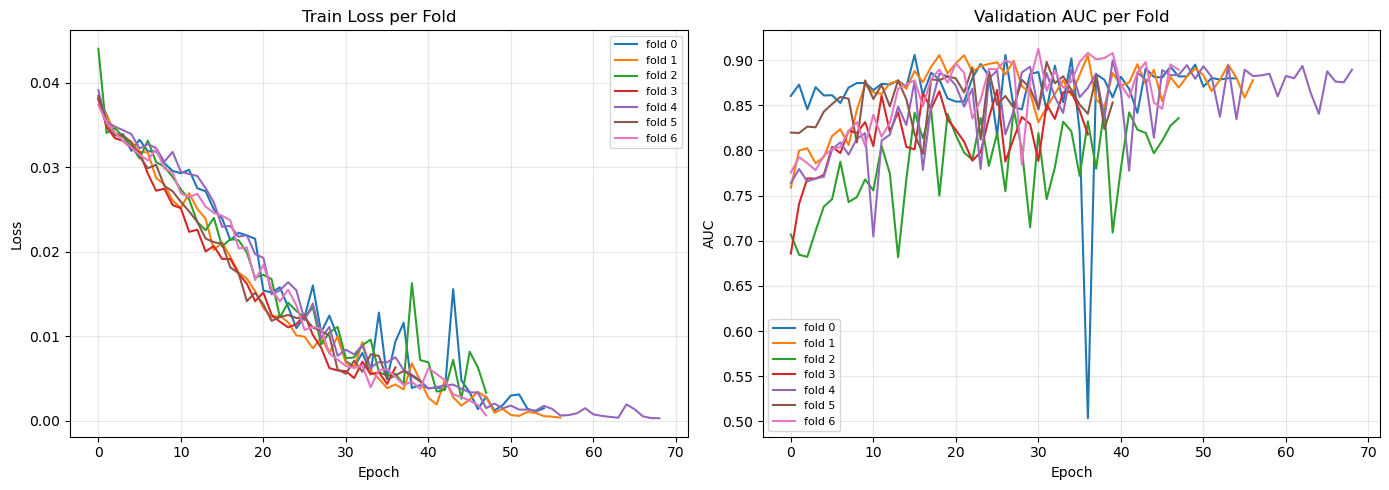

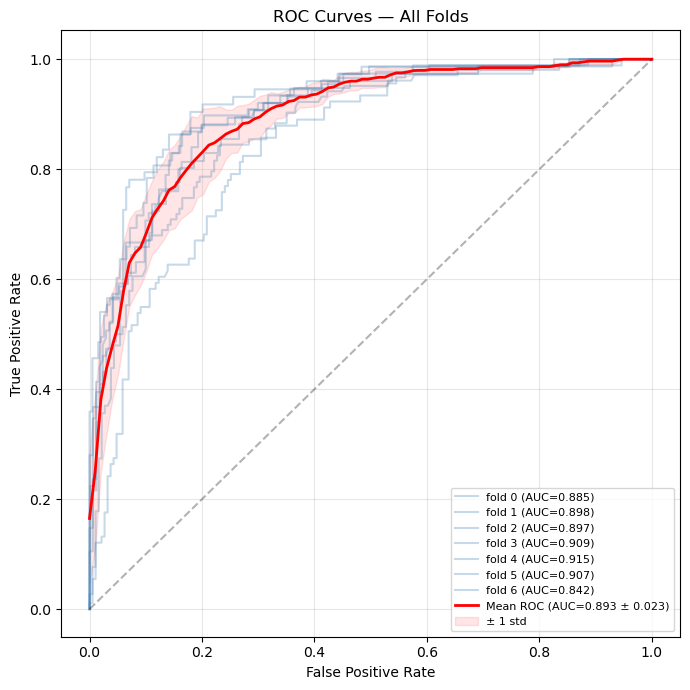

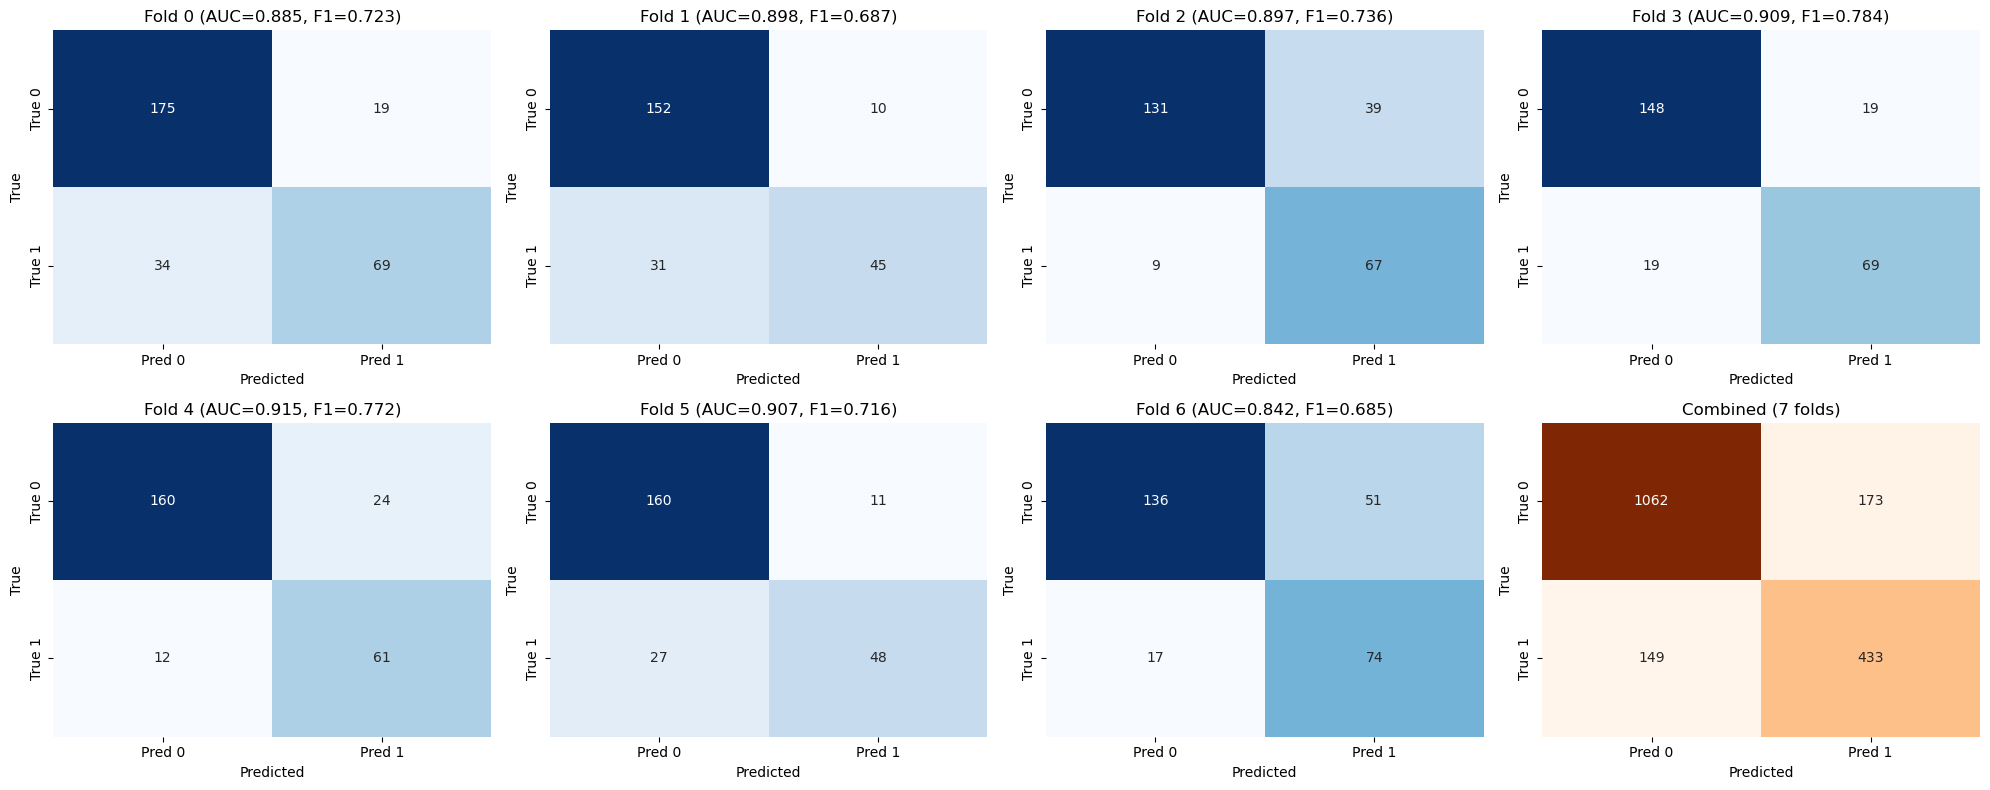

/tmp/ipykernel_501/3365572909.py:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=metrics, showmeans=True, meanline=True,


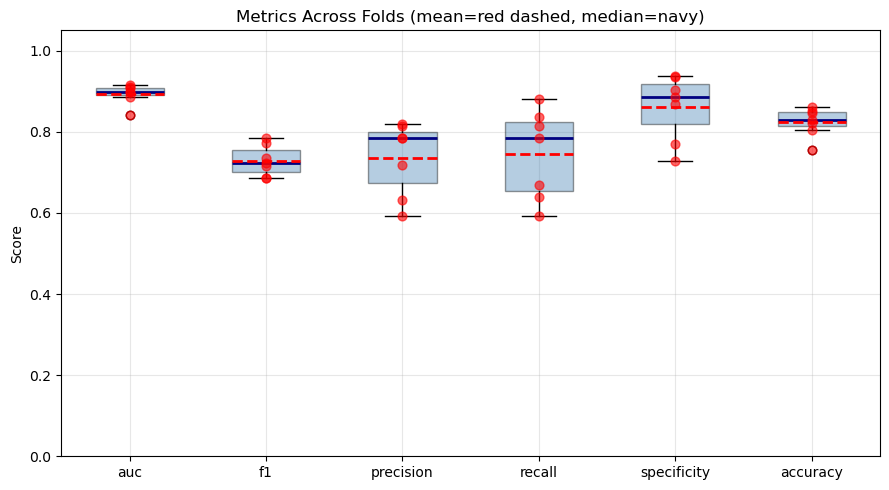


✓ All plots saved to: MTA_atrophy_CNN/results_mta_atrophy/final_best_config_macroF1


In [ ]:
summary_cnn = aggregate_results_binary(all_results_cnn)
generate_experiment_report(all_results_cnn, summary_cnn, FINAL_DIR, EXPERIMENT_NAME)

Device: cuda
Holdout: 98 patients, 203 images, 32.5% positive
  ✓ Fold 0 loaded  (test AUC=0.885  thr=0.325)
  ✓ Fold 1 loaded  (test AUC=0.898  thr=0.465)
  ✓ Fold 2 loaded  (test AUC=0.897  thr=0.690)
  ✓ Fold 3 loaded  (test AUC=0.909  thr=0.715)
  ✓ Fold 4 loaded  (test AUC=0.915  thr=0.555)
  ✓ Fold 5 loaded  (test AUC=0.907  thr=0.705)
  ✓ Fold 6 loaded  (test AUC=0.842  thr=0.510)

Building holdout loader...
  Preloaded 203 images (0.72 GB)


/tmp/ipykernel_501/3983712923.py:94: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ✓ Fold 0 inference done  (channels=standard_4)
  ✓ Fold 1 inference done  (channels=standard_4)
  ✓ Fold 2 inference done  (channels=standard_4)
  ✓ Fold 3 inference done  (channels=standard_4)
  ✓ Fold 4 inference done  (channels=standard_4)
  ✓ Fold 5 inference done  (channels=standard_4)
  ✓ Fold 6 inference done  (channels=standard_4)

  ENSEMBLE — HOLDOUT SET  (7 models × 203 samples)

───────────────────────────────────────────────────────
  MAJORITY VOTE (hard, per-fold thresholds)
───────────────────────────────────────────────────────
  AUC=0.946  F1=0.809  Acc=0.867  Thr=0.500
  Prec=0.760  Rec=0.864  Spec=0.869
  TP=57  FP=18  TN=119  FN=9
              precision    recall  f1-score   support

 Healthy (0)      0.930     0.869     0.898       137
Atrophic (1)      0.760     0.864     0.809        66

    accuracy                          0.867       203
   macro avg      0.845     0.866     0.853       203
weighted avg      0.875     0.867     0.869       203


───────────

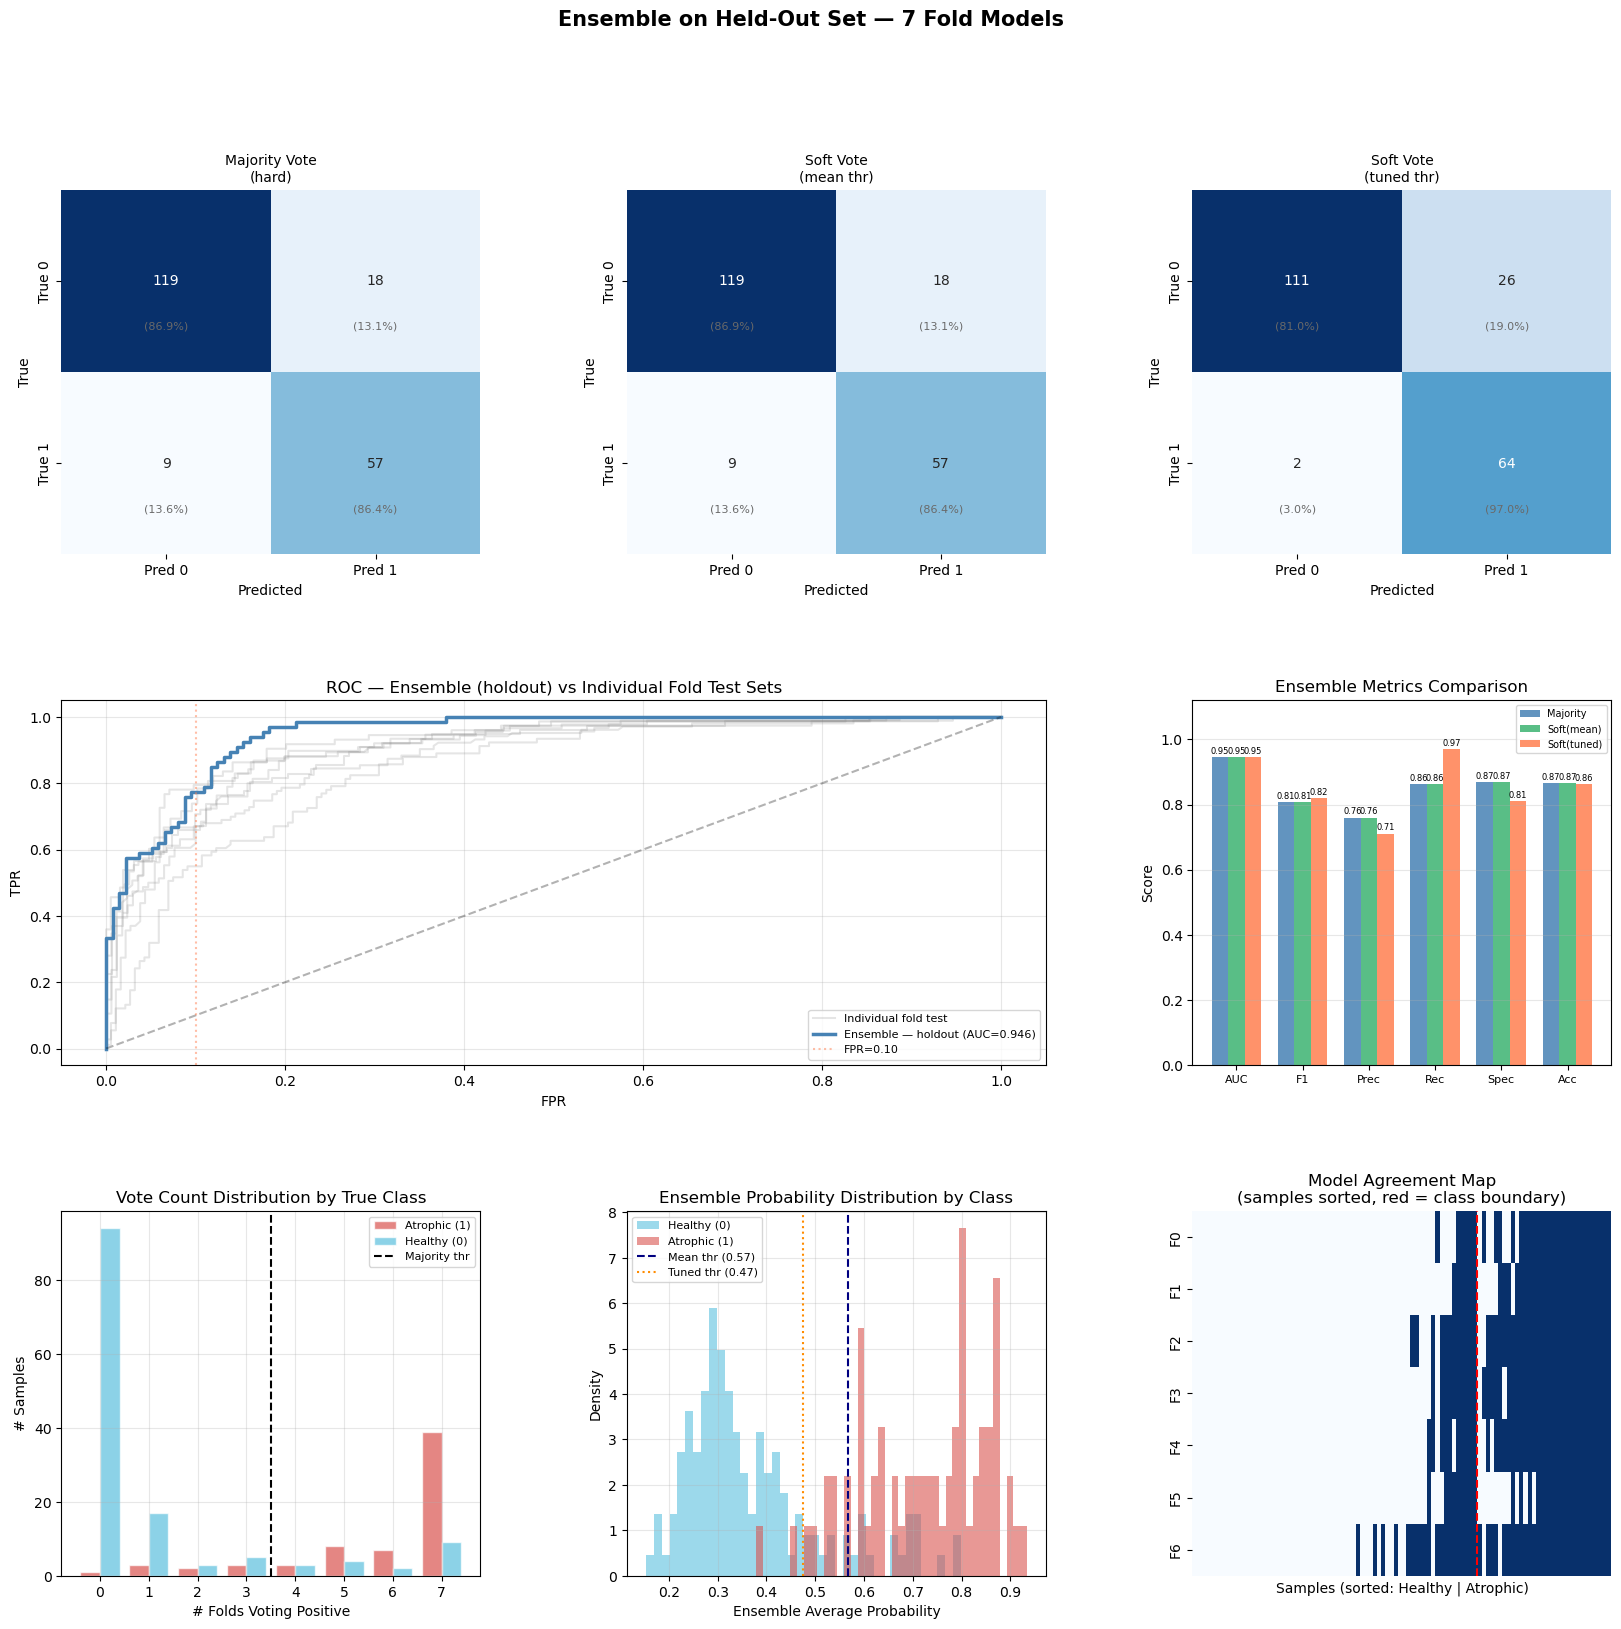


✓ Plot saved → MTA_atrophy_CNN/results_mta_atrophy/final_best_config_macroF1/ensemble_holdout_voting.png
✓ Results saved → MTA_atrophy_CNN/results_mta_atrophy/final_best_config_macroF1/ensemble_holdout_results.json


In [ ]:
import os, json, pickle, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

# ── Paths ────────────────────────────────────────────────────
PREP_DIR        = Path("../images/MRI_preprocessed")
LABELS_CSV      = Path("../labels/MTA_labels.csv")
RESULTS_DIR_CNN = Path("MTA_atrophy_CNN/results_mta_atrophy")
FINAL_DIR       = RESULTS_DIR_CNN / "final_best_config_macroF1"

BATCH_SIZE  = 16
NUM_WORKERS = 4
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Architecture ─────────────────────────────────────────────
CHANNEL_CONFIGS = {
    "narrow_3":   (8,  16,  32),
    "narrow_4":   (8,  16,  32,  64),
    "standard_4": (16, 32,  64, 128),
    "wide_4":     (32, 64, 128, 256),
}

class Small3DCNN(nn.Module):
    def __init__(self, n_targets=1, dropout=0.3, channels=(16, 32, 64, 128)):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv3d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm3d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool3d(2)
            )
        layers = [block(1, channels[0])]
        for i in range(len(channels) - 1):
            layers.append(block(channels[i], channels[i + 1]))
        self.backbone    = nn.Sequential(*layers)
        self.global_pool = nn.AdaptiveAvgPool3d(1)
        self.dropout     = nn.Dropout(dropout)
        self.head        = nn.Linear(channels[-1], n_targets)

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.global_pool(feat).flatten(1)
        feat = self.dropout(feat)
        return self.head(feat).squeeze(1)

# ── Dataset ──────────────────────────────────────────────────
class ADNIDataset(Dataset):
    def __init__(self, df, prep_dir, target_col='MTA_ATROPHY', preload=True):
        self.image_ids      = df['image_id'].tolist()
        self.targets        = df[target_col].values.astype(np.float32)
        self.sample_weights = df['sample_weight'].values.astype(np.float32)
        self.prep_dir       = prep_dir
        if preload:
            self.cache = [
                np.load(prep_dir / f"{i}.npy").astype(np.float32)
                for i in self.image_ids
            ]
            print(f"  Preloaded {len(self.cache)} images "
                  f"({sum(a.nbytes for a in self.cache)/1e9:.2f} GB)")
        else:
            self.cache = None

    def __len__(self): return len(self.image_ids)

    def __getitem__(self, idx):
        arr = self.cache[idx] if self.cache else \
              np.load(self.prep_dir / f"{self.image_ids[idx]}.npy").astype(np.float32)
        return (torch.from_numpy(arr[None]).float(),
                torch.tensor(self.targets[idx]),
                torch.tensor(self.sample_weights[idx]))

# ── Helpers ───────────────────────────────────────────────────
def run_inference(model, loader, device):
    model.eval()
    all_logits = []
    with torch.no_grad():
        for x, _, _ in loader:
            x = x.to(device, non_blocking=True)
            with autocast():
                logits = model(x)
            all_logits.append(logits.float().cpu())
    return torch.sigmoid(torch.cat(all_logits)).numpy()

def find_best_threshold(probs, labels, n=101, min_thr=0.3):
    best_score, best_thr = 0.0, 0.5
    for thr in np.linspace(min_thr, 0.8, n):
        pred = (probs >= thr).astype(int)
        try:    score = roc_auc_score(labels, pred)
        except: score = 0.0
        if score > best_score:
            best_score, best_thr = score, thr
    return best_thr, best_score

def full_metrics(preds, probs, labels, thr, label=""):
    try:    auc = roc_auc_score(labels, probs)
    except: auc = float('nan')
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary', zero_division=0)
    tn, fp, fn, tp   = confusion_matrix(labels, preds, labels=[0,1]).ravel()
    spec = tn/(tn+fp) if (tn+fp) > 0 else float('nan')
    acc  = float((preds == labels).mean())
    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")
    print(f"  AUC={auc:.3f}  F1={f1:.3f}  Acc={acc:.3f}  Thr={thr:.3f}")
    print(f"  Prec={prec:.3f}  Rec={rec:.3f}  Spec={spec:.3f}")
    print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
    print(classification_report(labels, preds,
          target_names=['Healthy (0)', 'Atrophic (1)'], digits=3))
    return dict(auc=auc, f1=f1, precision=prec, recall=rec,
                specificity=spec, accuracy=acc, threshold=thr,
                TP=int(tp), FP=int(fp), TN=int(tn), FN=int(fn))

# =================================================================
# 1. Load labels + holdout set from disk
# =================================================================
labels_init = pd.read_csv(LABELS_CSV)
labels_init['has_file'] = labels_init['image_id'].apply(
    lambda i: (PREP_DIR / f"{i}.npy").exists())
labels_all = labels_init[labels_init['has_file']].drop(columns='has_file').reset_index(drop=True)
n_neg, n_pos = (labels_all['MTA_ATROPHY'] == 0).sum(), (labels_all['MTA_ATROPHY'] == 1).sum()
labels_all['sample_weight'] = labels_all['MTA_ATROPHY'].apply(
    lambda y: (n_neg/n_pos)**0.5 if y == 1 else 1.0)

with open(RESULTS_DIR_CNN / "holdout_inference_set.json") as f:
    holdout = json.load(f)

holdout_df  = labels_all[labels_all['image_id'].isin(holdout['image_ids'])].reset_index(drop=True)
true_labels = np.array(holdout['labels'])
print(f"Holdout: {holdout['n_patients']} patients, {holdout['n_total']} images, "
      f"{100*holdout['positive_rate']:.1f}% positive")

# =================================================================
# 2. Load fold results from .pkl (for thresholds + configs)
# =================================================================
N_FOLDS = 7
all_results_cnn = []
for fold_idx in range(N_FOLDS):
    pkl_path = FINAL_DIR / f"fold_{fold_idx}.pkl"
    if not pkl_path.exists():
        raise FileNotFoundError(f"Missing: {pkl_path}")
    with open(pkl_path, 'rb') as f:
        all_results_cnn.append(pickle.load(f))
    print(f"  ✓ Fold {fold_idx} loaded  "
          f"(test AUC={all_results_cnn[-1]['test_results']['auc']:.3f}  "
          f"thr={all_results_cnn[-1]['test_results']['threshold']:.3f})")

# ========================(========================================
# 3. Build holdout loader
# =================================================================
print("\nBuilding holdout loader...")
holdout_ds     = ADNIDataset(holdout_df, PREP_DIR, target_col='MTA_ATROPHY', preload=True)
holdout_loader = DataLoader(holdout_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True,
                             persistent_workers=True)

# =================================================================
# 4. Load each .pt model and run inference on holdout
# =================================================================
fold_probs      = []
fold_thresholds = []

for fold_idx, res in enumerate(all_results_cnn):
    model_path = FINAL_DIR / f"fold_{fold_idx}_best_model.pt"
    if not model_path.exists():
        raise FileNotFoundError(f"Missing weights: {model_path}")

    cfg      = res['config']
    channels = CHANNEL_CONFIGS[cfg['channels_key']]
    model    = Small3DCNN(n_targets=1, dropout=cfg['dropout'], channels=channels).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))

    probs = run_inference(model, holdout_loader, DEVICE)
    fold_probs.append(probs)
    fold_thresholds.append(res['test_results']['threshold'])

    del model
    torch.cuda.empty_cache()
    print(f"  ✓ Fold {fold_idx} inference done  (channels={cfg['channels_key']})")

fold_probs      = np.stack(fold_probs, axis=0)
fold_thresholds = np.array(fold_thresholds)

# =================================================================
# 5. Ensemble predictions
# =================================================================
hard_votes       = (fold_probs >= fold_thresholds[:, None]).astype(int)
majority_pred    = (hard_votes.mean(axis=0) >= 0.5).astype(int)
vote_count       = hard_votes.sum(axis=0)

avg_probs        = fold_probs.mean(axis=0)
mean_thr         = float(fold_thresholds.mean())
soft_pred        = (avg_probs >= mean_thr).astype(int)

best_thr_soft, _ = find_best_threshold(avg_probs, true_labels)
soft_tuned_pred  = (avg_probs >= best_thr_soft).astype(int)

# =================================================================
# 6. Metrics
# =================================================================
print("\n" + "="*65)
print(f"  ENSEMBLE — HOLDOUT SET  ({N_FOLDS} models × {len(holdout_df)} samples)")
print("="*65)
mv_metrics  = full_metrics(majority_pred,    avg_probs, true_labels,
                            thr=0.5,           label="MAJORITY VOTE (hard, per-fold thresholds)")
sv_metrics  = full_metrics(soft_pred,         avg_probs, true_labels,
                            thr=mean_thr,       label="SOFT VOTE (mean prob, mean threshold)")
svt_metrics = full_metrics(soft_tuned_pred,   avg_probs, true_labels,
                            thr=best_thr_soft,  label="SOFT VOTE (mean prob, tuned threshold)")

# =================================================================
# 7. Plots
# =================================================================
fig = plt.figure(figsize=(20, 18))
fig.suptitle(f"Ensemble on Held-Out Set — {N_FOLDS} Fold Models",
             fontsize=15, fontweight='bold')
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.35)

# ── Row 0: confusion matrices ────────────────────────────────
for col, (preds, title) in enumerate([
    (majority_pred,   "Majority Vote\n(hard)"),
    (soft_pred,       "Soft Vote\n(mean thr)"),
    (soft_tuned_pred, "Soft Vote\n(tuned thr)"),
]):
    ax = fig.add_subplot(gs[0, col])
    cm = confusion_matrix(true_labels, preds, labels=[0,1])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.75, f"({100*cm_pct[i,j]:.1f}%)",
                    ha='center', va='center', fontsize=8, color='dimgray')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

# ── Row 1: ROC + metrics bar ─────────────────────────────────
ax_roc = fig.add_subplot(gs[1, 0:2])
fpr, tpr, _ = roc_curve(true_labels, avg_probs)
auc_ens = roc_auc_score(true_labels, avg_probs)
for i, res in enumerate(all_results_cnn):
    f, t, _ = roc_curve(np.array(res['test_labels']), np.array(res['test_probs']))
    ax_roc.plot(f, t, alpha=0.2, color='gray',
                label='Individual fold test' if i == 0 else '_nolegend_')
ax_roc.plot(fpr, tpr, color='steelblue', lw=2.5,
            label=f'Ensemble — holdout (AUC={auc_ens:.3f})')
ax_roc.plot([0,1],[0,1],'k--',alpha=0.3)
ax_roc.axvline(0.1, color='coral', ls=':', alpha=0.5, label='FPR=0.10')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title('ROC — Ensemble (holdout) vs Individual Fold Test Sets')
ax_roc.legend(loc='lower right', fontsize=8); ax_roc.grid(alpha=0.3)

ax_bar = fig.add_subplot(gs[1, 2])
keys  = ['auc','f1','precision','recall','specificity','accuracy']
names = ['AUC','F1','Prec','Rec','Spec','Acc']
x = np.arange(len(keys)); w = 0.25
ax_bar.bar(x-w, [mv_metrics[k]  for k in keys], w, label='Majority',    color='steelblue',      alpha=0.85)
ax_bar.bar(x,   [sv_metrics[k]  for k in keys], w, label='Soft(mean)',   color='mediumseagreen', alpha=0.85)
ax_bar.bar(x+w, [svt_metrics[k] for k in keys], w, label='Soft(tuned)', color='coral',          alpha=0.85)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(names, fontsize=8)
ax_bar.set_ylim(0, 1.12); ax_bar.set_ylabel('Score')
ax_bar.set_title('Ensemble Metrics Comparison')
ax_bar.legend(fontsize=7); ax_bar.grid(axis='y', alpha=0.3)
for bars in ax_bar.containers:
    ax_bar.bar_label(bars, fmt='%.2f', fontsize=6, padding=1)

# ── Row 2: vote dist + prob dist + agreement heatmap ─────────
ax_v = fig.add_subplot(gs[2, 0])
ax_v.hist([vote_count[true_labels==1], vote_count[true_labels==0]],
          bins=np.arange(-0.5,8.5), label=['Atrophic (1)','Healthy (0)'],
          color=['#d9534f','#5bc0de'], alpha=0.7, edgecolor='white')
ax_v.axvline(3.5, color='black', ls='--', lw=1.5, label='Majority thr')
ax_v.set_xlabel('# Folds Voting Positive'); ax_v.set_ylabel('# Samples')
ax_v.set_title('Vote Count Distribution by True Class')
ax_v.legend(fontsize=8); ax_v.grid(alpha=0.3); ax_v.set_xticks(range(8))

ax_p = fig.add_subplot(gs[2, 1])
ax_p.hist(avg_probs[true_labels==0], bins=40, alpha=0.6, color='#5bc0de',
          label='Healthy (0)', density=True)
ax_p.hist(avg_probs[true_labels==1], bins=40, alpha=0.6, color='#d9534f',
          label='Atrophic (1)', density=True)
ax_p.axvline(mean_thr,      color='navy',       ls='--', lw=1.5,
             label=f'Mean thr ({mean_thr:.2f})')
ax_p.axvline(best_thr_soft, color='darkorange', ls=':',  lw=1.5,
             label=f'Tuned thr ({best_thr_soft:.2f})')
ax_p.set_xlabel('Ensemble Average Probability'); ax_p.set_ylabel('Density')
ax_p.set_title('Ensemble Probability Distribution by Class')
ax_p.legend(fontsize=8); ax_p.grid(alpha=0.3)

ax_h = fig.add_subplot(gs[2, 2])
sort_idx  = np.lexsort((avg_probs, true_labels))
sample100 = sort_idx[np.linspace(0, len(sort_idx)-1, min(100, len(sort_idx)), dtype=int)]
sns.heatmap(hard_votes[:, sample100], cmap='Blues', cbar=False, ax=ax_h,
            xticklabels=False,
            yticklabels=[f"F{i}" for i in range(N_FOLDS)])
n_neg_sub = (true_labels[sample100] == 0).sum()
ax_h.axvline(n_neg_sub, color='red', lw=1.5, ls='--')
ax_h.set_xlabel('Samples (sorted: Healthy | Atrophic)')
ax_h.set_title('Model Agreement Map\n(samples sorted, red = class boundary)')

plt.savefig(FINAL_DIR / "ensemble_holdout_voting.png", dpi=130, bbox_inches='tight')
plt.show()
print(f"\n✓ Plot saved → {FINAL_DIR / 'ensemble_holdout_voting.png'}")

# =================================================================
# 8. Save results
# =================================================================
ensemble_out = {
    'n_folds':              N_FOLDS,
    'n_patients':           holdout['n_patients'],
    'n_samples':            int(len(holdout_df)),
    'n_positive':           int(true_labels.sum()),
    'positive_rate':        holdout['positive_rate'],
    'fold_thresholds':      fold_thresholds.tolist(),
    'majority_vote':        mv_metrics,
    'soft_vote_mean_thr':   sv_metrics,
    'soft_vote_tuned_thr':  svt_metrics,
    'avg_probs':            avg_probs.tolist(),
    'vote_counts':          vote_count.tolist(),
    'true_labels':          true_labels.tolist(),
    'image_ids':            holdout_df['image_id'].tolist(),
}
out_json = FINAL_DIR / "ensemble_holdout_results.json"
with open(out_json, 'w') as f:
    json.dump(ensemble_out, f, indent=2)
print(f"✓ Results saved → {out_json}")

# Demographic Fusion — best CNN config + [gender, age, education]

Reuses the best hyperparameters from the search. Adds a small MLP encoder for
demographics, concatenated with the CNN's pooled features before the head.
Backbone is identical to `Small3DCNN`, so everything else (loss, splits,
threshold tuning, metrics) is unchanged. Per-fold demographic scalers are fit on
**train only** to avoid leakage and saved inside each fold result.

In [45]:
# =================================================================
#  Demographic fusion — minimal additions on top of the CNN pipeline
# =================================================================
DEMO_COLS = ['PTGENDER', 'AGE', 'PTEDUCAT']
for c in DEMO_COLS:
    assert c in labels.columns, f"Missing column: {c}. Available: {list(labels.columns)}"

n_missing   = labels[DEMO_COLS].isna().any(axis=1).sum()
labels_demo = labels.dropna(subset=DEMO_COLS).reset_index(drop=True)
print(f"Dropped {n_missing} rows with missing demographics")
print(f"Using {len(labels_demo)} / {len(labels)} rows for demo-fusion experiment")


def fit_demo_scaler(train_df):
    """Fit normalisation stats on TRAIN fold only — prevents leakage."""
    return {
        'age_mean': float(train_df['AGE'].mean()),
        'age_std':  float(train_df['AGE'].std() + 1e-8),
        'edu_mean': float(train_df['PTEDUCAT'].mean()),
        'edu_std':  float(train_df['PTEDUCAT'].std() + 1e-8),
    }

def transform_demo(df, scaler):
    """Convert df → (N, 3) float32 array of [gender, age_z, edu_z]."""
    gender = (df['PTGENDER'].astype(str).str.upper().str[0] == 'F').astype(np.float32).values
    age    = ((df['AGE'].values      - scaler['age_mean']) / scaler['age_std']).astype(np.float32)
    edu    = ((df['PTEDUCAT'].values - scaler['edu_mean']) / scaler['edu_std']).astype(np.float32)
    return np.stack([gender, age, edu], axis=1)


class ADNIDatasetDemo(Dataset):
    """Wraps ADNIDataset; additionally returns demo vector. Returns (x, demo, y, w)."""
    def __init__(self, df, prep_dir, demo_array,
                 target_col='MTA_ATROPHY', preload=True, training=False):
        assert len(df) == len(demo_array), "demo_array length must match df"
        self.base = ADNIDataset(df, prep_dir, target_col=target_col, preload=preload)
        self.demo = torch.from_numpy(demo_array).float()
    def __len__(self):  return len(self.base)
    def __getitem__(self, idx):
        x, y, w = self.base[idx]
        return x, self.demo[idx], y, w


def evaluate_demo(model, loader, device):
    """Same as evaluate() but unpacks (x, demo, y, w) loaders."""
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for x, demo, y, w in loader:
            x    = x.to(device, non_blocking=True)
            demo = demo.to(device, non_blocking=True)
            with autocast():
                logits = model(x, demo)
            all_logits.append(logits.float().cpu())
            all_labels.append(y)
    probs  = torch.sigmoid(torch.cat(all_logits)).numpy()
    labels = torch.cat(all_labels).numpy()
    return probs, labels


class Small3DCNNDemo(nn.Module):
    """Small3DCNN backbone + demographic MLP, fused before the head."""
    def __init__(self, n_demo_features=3, demo_hidden=16,
                 n_targets=1, dropout=0.3, channels=(16, 32, 64, 128)):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv3d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm3d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool3d(2)
            )
        layers = [block(1, channels[0])]
        for i in range(len(channels) - 1):
            layers.append(block(channels[i], channels[i + 1]))
        self.backbone    = nn.Sequential(*layers)
        self.global_pool = nn.AdaptiveAvgPool3d(1)

        self.demo_encoder = nn.Sequential(
            nn.Linear(n_demo_features, demo_hidden),
            nn.ReLU(inplace=True),
            nn.Linear(demo_hidden, demo_hidden),
            nn.ReLU(inplace=True),
        )
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(channels[-1] + demo_hidden, n_targets)

    def forward(self, x, demo):
        feat = self.global_pool(self.backbone(x)).flatten(1)   # (B, C)
        d    = self.demo_encoder(demo)                         # (B, demo_hidden)
        z    = self.dropout(torch.cat([feat, d], dim=1))
        return self.head(z).squeeze(1)                         # (B,)

Dropped 0 rows with missing demographics
Using 2020 / 2020 rows for demo-fusion experiment


In [46]:
def train_one_fold_demo(fold_idx, splits, labels_df, prep_dir, device,
                        epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
                        weight_decay=WEIGHT_DECAY, patience=PATIENCE,
                        alpha=0.25, gamma=2.0, target_col='MTA_ATROPHY',
                        dropout=0.3, channels_key='standard_4',
                        demo_hidden=16, exp_dir=None, verbose=True):

    fold     = splits[fold_idx]
    train_df = labels_df[labels_df['PTID'].isin(fold['train_patients'])].reset_index(drop=True)
    val_df   = labels_df[labels_df['PTID'].isin(fold['val_patients'])].reset_index(drop=True)
    test_df  = labels_df[labels_df['PTID'].isin(fold['test_patients'])].reset_index(drop=True)

    if verbose:
        print(f"\n{'='*60}")
        print(f"Fold {fold_idx} | Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}")
        print(f"  channels={channels_key}  dropout={dropout}  demo_hidden={demo_hidden}")
        print(f"  lr={lr:.0e}  wd={weight_decay:.0e}  Focal(α={alpha}, γ={gamma})")
        print(f"{'='*60}")

    demo_scaler = fit_demo_scaler(train_df)
    train_demo  = transform_demo(train_df, demo_scaler)
    val_demo    = transform_demo(val_df,   demo_scaler)
    test_demo   = transform_demo(test_df,  demo_scaler)
    if verbose:
        print(f"  Demo scaler: age μ={demo_scaler['age_mean']:.1f} σ={demo_scaler['age_std']:.1f} | "
              f"edu μ={demo_scaler['edu_mean']:.1f} σ={demo_scaler['edu_std']:.1f}")

    train_ds = ADNIDatasetDemo(train_df, prep_dir, train_demo,
                               target_col=target_col, preload=True, training=True)
    val_ds   = ADNIDatasetDemo(val_df,   prep_dir, val_demo,
                               target_col=target_col, preload=True, training=False)
    test_ds  = ADNIDatasetDemo(test_df,  prep_dir, test_demo,
                               target_col=target_col, preload=True, training=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

    channels  = CHANNEL_CONFIGS[channels_key]
    model     = Small3DCNNDemo(n_demo_features=3, demo_hidden=demo_hidden,
                               n_targets=1, dropout=dropout, channels=channels).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = FocalLoss(alpha=alpha, gamma=gamma)
    scaler    = GradScaler()

    best_val_score, best_epoch, best_state = -1.0, -1, None
    epochs_no_improve = 0
    history = []

    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        train_loss_sum, train_n = 0.0, 0
        for x, demo, y, w in train_loader:
            x    = x.to(device, non_blocking=True)
            demo = demo.to(device, non_blocking=True)
            y    = y.to(device, non_blocking=True)
            w    = w.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast():
                logits = model(x, demo)
                loss   = criterion(logits, y, sample_weights=w)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss_sum += loss.item() * x.size(0)
            train_n        += x.size(0)
        scheduler.step()
        train_loss = train_loss_sum / train_n

        val_probs, val_labels = evaluate_demo(model, val_loader, device)
        try:    val_auc = roc_auc_score(val_labels, val_probs)
        except: val_auc = float('nan')
        best_thr_val, _       = find_best_threshold(val_probs, val_labels)
        val_preds             = (val_probs >= best_thr_val).astype(int)
        _, _, val_f1_macro, _ = precision_recall_fscore_support(
            val_labels, val_preds, average='macro', zero_division=0)

        epoch_time = time.time() - t0
        history.append({'epoch': epoch, 'train_loss': train_loss,
                        'val_auc': val_auc, 'val_f1_macro': val_f1_macro,
                        'time_sec': epoch_time})
        if verbose:
            print(f"  ep {epoch:2d}  loss={train_loss:.4f}  "
                  f"val_AUC={val_auc:.3f}  val_macroF1={val_f1_macro:.3f}  [{epoch_time:.0f}s]")

        if val_f1_macro > best_val_score:
            best_val_score    = val_f1_macro
            best_epoch        = epoch
            best_state        = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  ⏹  Early stopping at epoch {epoch} (best: {best_epoch})")
                break

    # ---- Save weights ----
    if exp_dir is not None:
        torch.save(best_state, exp_dir / f"fold_{fold_idx}_best_model.pt")
        if verbose:
            print(f"  ✓ Weights saved → fold_{fold_idx}_best_model.pt")

    # ---- Test evaluation ----
    model.load_state_dict(best_state)
    val_probs, val_labels   = evaluate_demo(model, val_loader, device)
    best_thr, _             = find_best_threshold(val_probs, val_labels)
    test_probs, test_labels = evaluate_demo(model, test_loader, device)
    test_preds = (test_probs >= best_thr).astype(int)

    try:    auc = roc_auc_score(test_labels, test_probs)
    except: auc = float('nan')
    prec, rec, f1, _ = precision_recall_fscore_support(
        test_labels, test_preds, average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(test_labels, test_preds, labels=[0, 1]).ravel()

    test_results = {
        'threshold':   float(best_thr),
        'auc':         float(auc),
        'f1':          float(f1),
        'precision':   float(prec),
        'recall':      float(rec),
        'specificity': float(tn / (tn + fp)) if (tn + fp) > 0 else float('nan'),
        'accuracy':    float((test_preds == test_labels).mean()),
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'n_total':    int(len(test_labels)),
        'n_positive': int(test_labels.sum()),
    }

    if verbose:
        print(f"\n  ✓ Best epoch: {best_epoch} | val macroF1: {best_val_score:.3f}")
        print(f"  ✓ Threshold: {best_thr:.3f} | AUC: {auc:.3f}")
        print(f"\n  TEST RESULTS:")
        print(classification_report(test_labels, test_preds,
              target_names=['Healthy (0)', 'Atrophic (1)'], digits=3))
        print(f"  Specificity: {test_results['specificity']:.3f}")
        print(f"  TP={tp} FP={fp} TN={tn} FN={fn}")

    del train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, model
    torch.cuda.empty_cache()

    return {
        'fold':          fold_idx,
        'best_epoch':    best_epoch,
        'best_val_auc':  best_val_score,   # stores macroF1
        'test_results':  test_results,
        'test_probs':    test_probs.tolist(),
        'test_labels':   test_labels.tolist(),
        'history':       history,
        'demo_scaler':   demo_scaler,
        'config': {
            'alpha': alpha, 'gamma': gamma, 'dropout': dropout,
            'channels_key': channels_key, 'lr': lr,
            'weight_decay': weight_decay, 'target_col': target_col,
            'demo_hidden': demo_hidden, 'model': 'small3dcnn_demo',
        },
    }


def run_all_folds_demo(splits, labels_df, prep_dir, device, exp_dir,
                       alpha=0.25, gamma=2.0, target_col='MTA_ATROPHY',
                       epochs=EPOCHS, patience=PATIENCE,
                       dropout=0.3, channels_key='standard_4',
                       demo_hidden=16, lr=LR, weight_decay=WEIGHT_DECAY):
    all_results = []
    total_t0    = time.time()
    for fold_idx in range(len(splits)):
        fold_file = exp_dir / f"fold_{fold_idx}.pkl"
        if fold_file.exists():
            print(f"\n[skip] Fold {fold_idx} already done — loading from disk")
            with open(fold_file, 'rb') as f:
                all_results.append(pickle.load(f))
            continue
        result = train_one_fold_demo(
            fold_idx=fold_idx, splits=splits, labels_df=labels_df,
            prep_dir=prep_dir, device=device,
            epochs=epochs, patience=patience,
            lr=lr, weight_decay=weight_decay,
            alpha=alpha, gamma=gamma,
            dropout=dropout, channels_key=channels_key,
            demo_hidden=demo_hidden, target_col=target_col,
            exp_dir=exp_dir, verbose=True,
        )
        with open(fold_file, 'wb') as f:
            pickle.dump(result, f)
        all_results.append(result)

        elapsed = (time.time() - total_t0) / 60
        eta     = elapsed / (fold_idx + 1) * (len(splits) - fold_idx - 1)
        aucs    = [r['test_results']['auc'] for r in all_results]
        f1s     = [r['test_results']['f1']  for r in all_results]
        print(f"\n📊 Cumulative ({fold_idx+1}/{len(splits)}) — elapsed {elapsed:.0f}m, ETA {eta:.0f}m")
        print(f"     AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
        print(f"     F1  = {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
    return all_results

Demo-fusion config (inherited from CNN search):
  lr              = 0.001
  weight_decay    = 0.001
  dropout         = 0.2
  channels_key    = standard_4
  focal_alpha     = 0.25
  focal_gamma     = 3.0
  demo_hidden     = 16

✓ Output dir: MTA_atrophy_CNN/results_mta_atrophy/final_demo_fusion_macroF1

Fold 0 | Train 1314 | Val 206 | Test 297
  channels=standard_4  dropout=0.2  demo_hidden=16
  lr=1e-03  wd=1e-03  Focal(α=0.25, γ=3.0)
  Demo scaler: age μ=74.2 σ=7.7 | edu μ=16.4 σ=2.6
  Preloaded 1314 images (4.65 GB)
  Preloaded 206 images (0.73 GB)
  Preloaded 297 images (1.05 GB)


/tmp/ipykernel_501/1207665452.py:48: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_501/1207665452.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/2053564494.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ep  0  loss=0.0381  val_AUC=0.844  val_macroF1=0.709  [9s]


/tmp/ipykernel_501/1207665452.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/2053564494.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ep  1  loss=0.0337  val_AUC=0.864  val_macroF1=0.652  [9s]


...

  ep 44  loss=0.0028  val_AUC=0.902  val_macroF1=0.793  [9s]


/tmp/ipykernel_501/1207665452.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/2053564494.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ep 45  loss=0.0038  val_AUC=0.887  val_macroF1=0.733  [9s]
  ⏹  Early stopping at epoch 45 (best: 25)
  ✓ Weights saved → fold_6_best_model.pt


/tmp/ipykernel_501/2053564494.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_501/2053564494.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



  ✓ Best epoch: 25 | val macroF1: 0.849
  ✓ Threshold: 0.300 | AUC: 0.878

  TEST RESULTS:
              precision    recall  f1-score   support

 Healthy (0)      0.857     0.866     0.862       187
Atrophic (1)      0.719     0.703     0.711        91

    accuracy                          0.813       278
   macro avg      0.788     0.785     0.786       278
weighted avg      0.812     0.813     0.812       278

  Specificity: 0.866
  TP=64 FP=25 TN=162 FN=27

📊 Cumulative (7/7) — elapsed 57m, ETA 0m
     AUC = 0.893 ± 0.023
     F1  = 0.725 ± 0.049

✓ ALL FOLDS COMPLETE — demo fusion

  FINAL RESULTS — small3dcnn_demo
  7 folds
Metric          |       Mean |        Std |      Min |      Max
------------------------------------------------------------
  auc           |      0.893 |      0.023 |    0.860 |    0.933
  f1            |      0.725 |      0.049 |    0.667 |    0.800
  precision     |      0.755 |      0.061 |    0.681 |    0.878
  recall        |      0.712 |      0.108 |

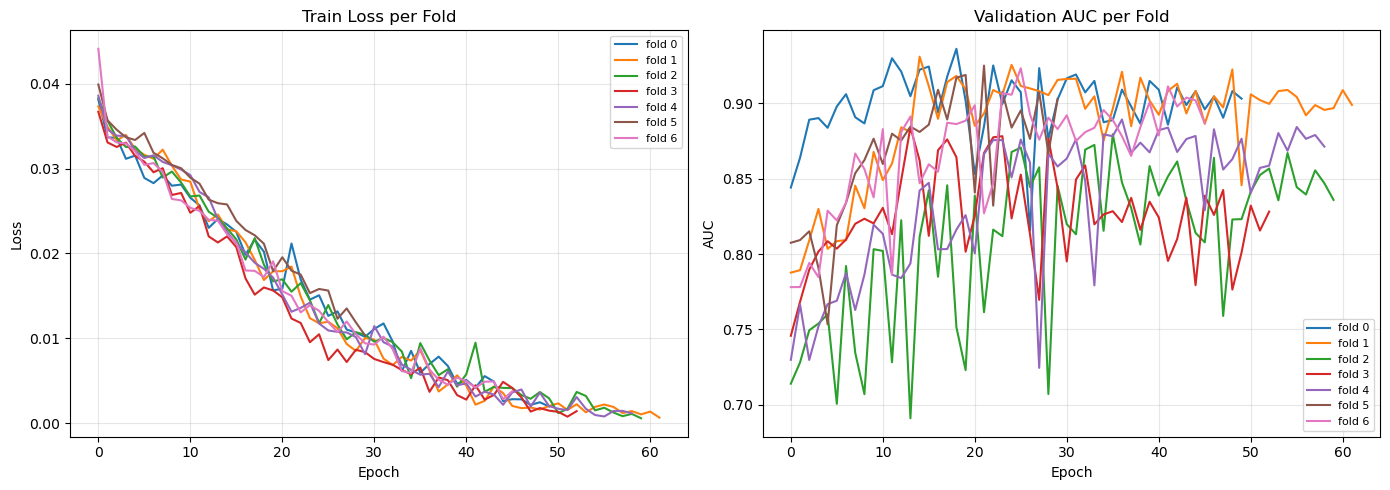

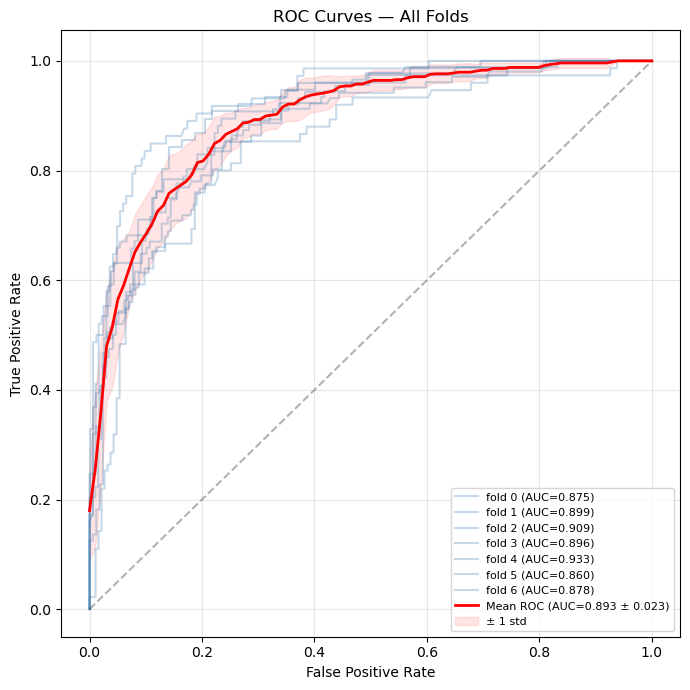

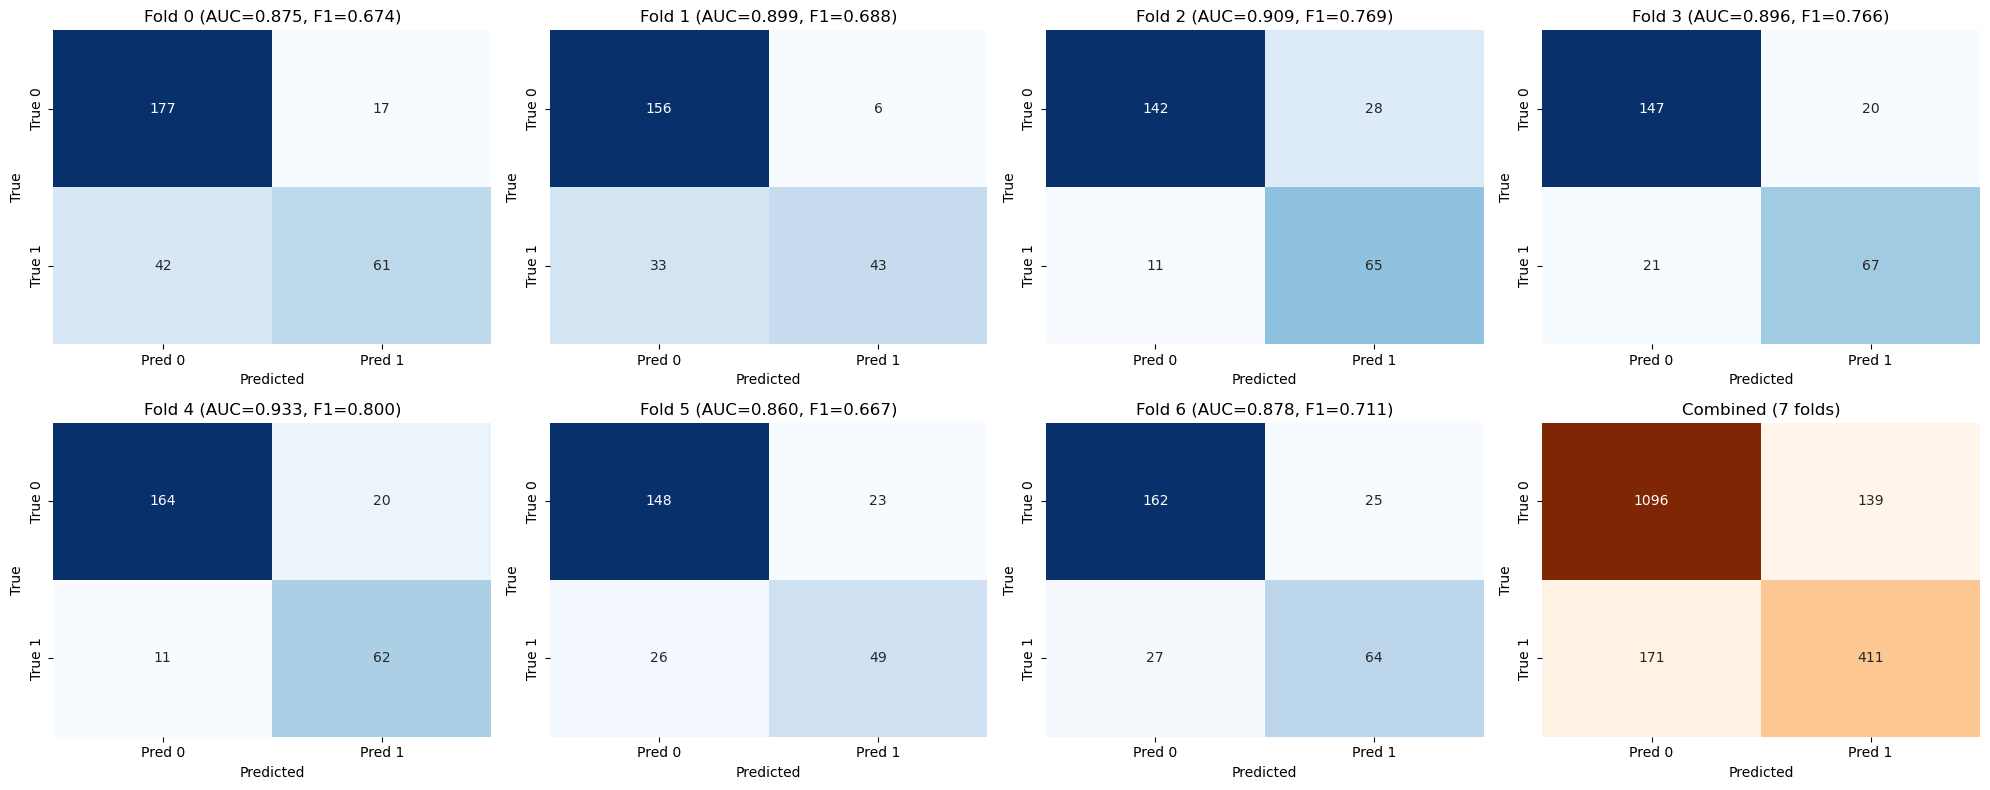

/tmp/ipykernel_501/3365572909.py:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=metrics, showmeans=True, meanline=True,


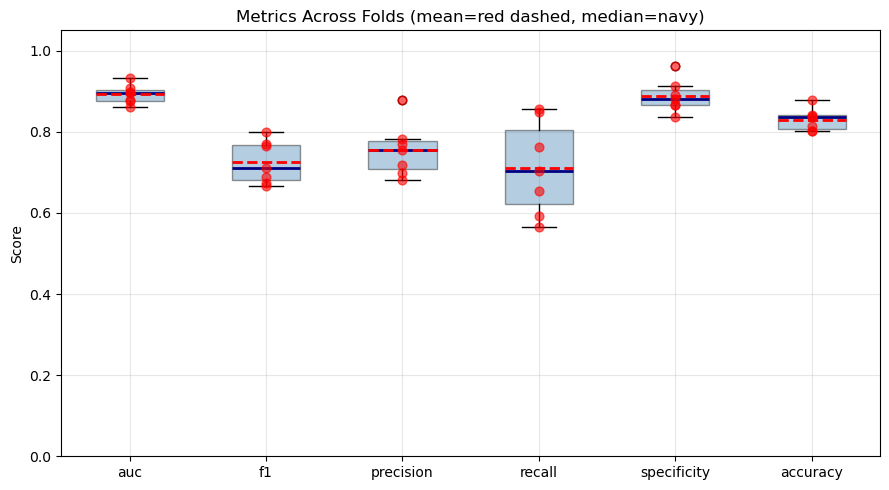


✓ All plots saved to: MTA_atrophy_CNN/results_mta_atrophy/final_demo_fusion_macroF1


In [47]:
import shutil

# Reuse best CNN config from the search; demo_hidden fixed (matches MedNet default)
DEMO_HIDDEN = 16
print("Demo-fusion config (inherited from CNN search):")
for k, v in best_cfg.items():
    print(f"  {k:<15} = {v}")
print(f"  {'demo_hidden':<15} = {DEMO_HIDDEN}")

FINAL_DIR_DEMO = RESULTS_DIR_CNN / "final_demo_fusion_macroF1"
shutil.rmtree(FINAL_DIR_DEMO, ignore_errors=True)
FINAL_DIR_DEMO.mkdir(exist_ok=True)
print(f"\n✓ Output dir: {FINAL_DIR_DEMO}")

all_results_demo = run_all_folds_demo(
    splits=splits, labels_df=labels_demo,
    prep_dir=PREP_DIR, device=DEVICE,
    exp_dir=FINAL_DIR_DEMO,
    lr=best_cfg["lr"],
    weight_decay=best_cfg["weight_decay"],
    alpha=best_cfg["focal_alpha"],
    gamma=best_cfg["focal_gamma"],
    dropout=best_cfg["dropout"],
    channels_key=best_cfg["channels_key"],
    demo_hidden=DEMO_HIDDEN,
    target_col='MTA_ATROPHY',
    epochs=EPOCHS,
    patience=PATIENCE,
)

print(f"\n{'='*55}")
print(f"✓ ALL FOLDS COMPLETE — demo fusion")
print(f"{'='*55}")

summary_demo = aggregate_results_binary(all_results_demo)
generate_experiment_report(all_results_demo, summary_demo, FINAL_DIR_DEMO, "small3dcnn_demo")

Holdout: 98 patients, 203 images, 32.5% positive
  ✓ Fold 0 loaded  (test AUC=0.875  thr=0.355)
  ✓ Fold 1 loaded  (test AUC=0.899  thr=0.645)
  ✓ Fold 2 loaded  (test AUC=0.909  thr=0.595)
  ✓ Fold 3 loaded  (test AUC=0.896  thr=0.535)
  ✓ Fold 4 loaded  (test AUC=0.933  thr=0.795)
  ✓ Fold 5 loaded  (test AUC=0.860  thr=0.715)
  ✓ Fold 6 loaded  (test AUC=0.878  thr=0.300)

Preloading holdout images once...
  Preloaded 203 images


/tmp/ipykernel_501/2053564494.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ✓ Fold 0 inference done


/tmp/ipykernel_501/2053564494.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ✓ Fold 1 inference done


...

  ✓ Fold 4 inference done


/tmp/ipykernel_501/2053564494.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ✓ Fold 5 inference done


/tmp/ipykernel_501/2053564494.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ✓ Fold 6 inference done

  DEMO-FUSION ENSEMBLE — HOLDOUT SET  (7 models × 203 samples)

───────────────────────────────────────────────────────
  MAJORITY VOTE (hard, per-fold thresholds)
───────────────────────────────────────────────────────
  AUC=0.965  F1=0.851  Acc=0.897  Thr=0.500
  Prec=0.800  Rec=0.909  Spec=0.891
  TP=60  FP=15  TN=122  FN=6
              precision    recall  f1-score   support

 Healthy (0)      0.953     0.891     0.921       137
Atrophic (1)      0.800     0.909     0.851        66

    accuracy                          0.897       203
   macro avg      0.877     0.900     0.886       203
weighted avg      0.903     0.897     0.898       203


───────────────────────────────────────────────────────
  SOFT VOTE (mean prob, mean threshold)
───────────────────────────────────────────────────────
  AUC=0.965  F1=0.835  Acc=0.887  Thr=0.563
  Prec=0.795  Rec=0.879  Spec=0.891
  TP=58  FP=15  TN=122  FN=8
              precision    recall  f1-score   support



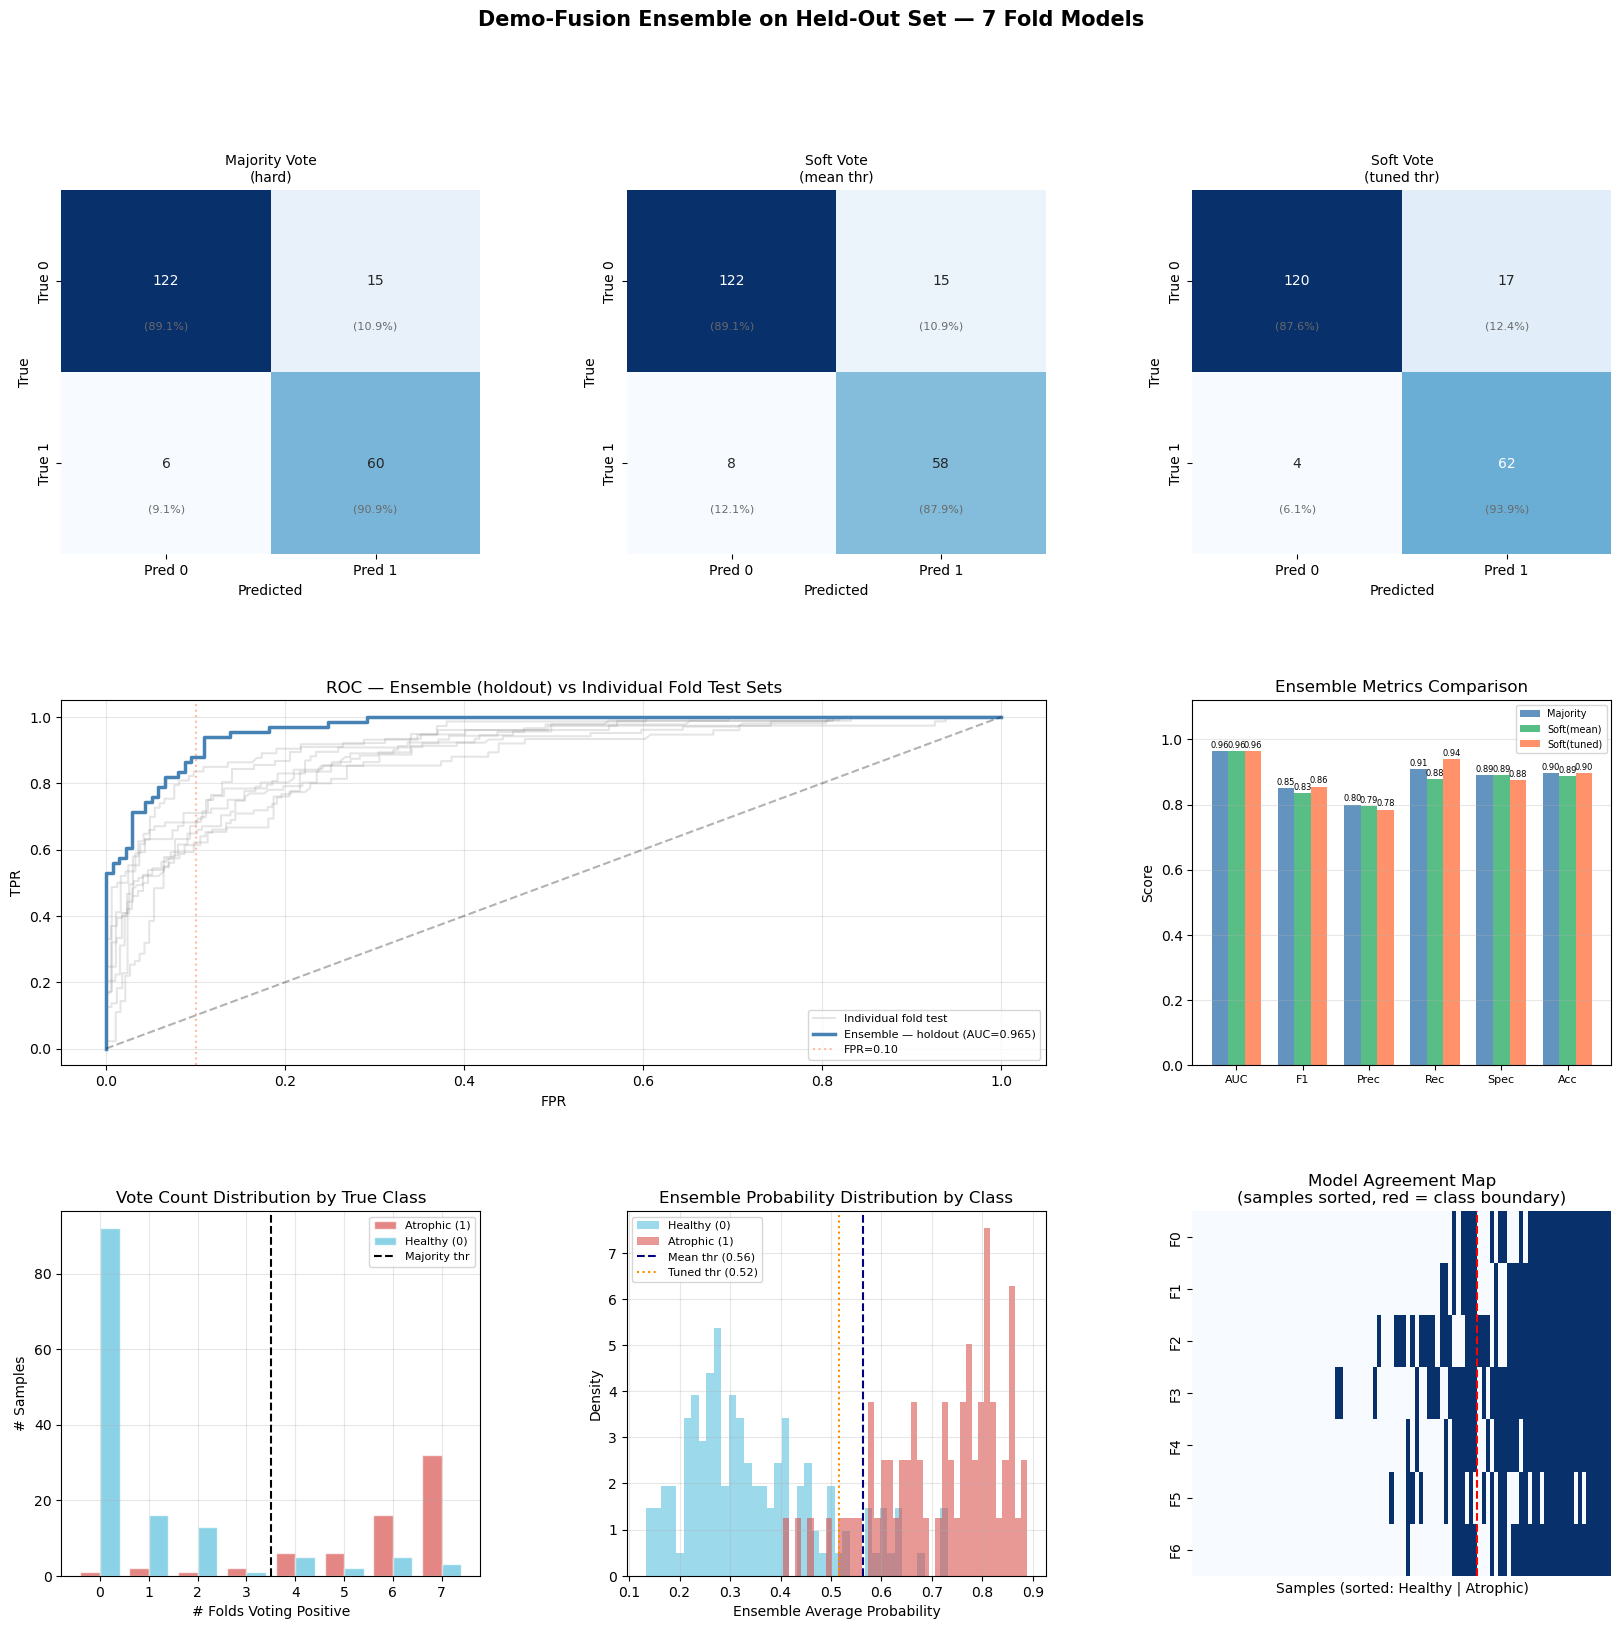


✓ Plot saved → MTA_atrophy_CNN/results_mta_atrophy/final_demo_fusion_macroF1/ensemble_holdout_voting.png
✓ Results saved → MTA_atrophy_CNN/results_mta_atrophy/final_demo_fusion_macroF1/ensemble_holdout_results.json


In [48]:
# =================================================================
#  Demo-fusion — hold-out ensemble inference
#  (mirrors the CNN ensemble cell; each fold uses its own demo_scaler)
# =================================================================
import seaborn as sns
from sklearn.metrics import roc_curve, classification_report

FINAL_DIR_DEMO = RESULTS_DIR_CNN / "final_demo_fusion_macroF1"

with open(RESULTS_DIR_CNN / "holdout_inference_set.json") as f:
    holdout = json.load(f)

# Filter hold-out to rows with demographics (must match training-set filtering)
holdout_df  = labels_demo[labels_demo['image_id'].isin(holdout['image_ids'])].reset_index(drop=True)
true_labels = holdout_df['MTA_ATROPHY'].values.astype(int)
n_dropped   = holdout['n_total'] - len(holdout_df)
print(f"Holdout: {holdout_df['PTID'].nunique()} patients, {len(holdout_df)} images, "
      f"{100*true_labels.mean():.1f}% positive"
      + (f"  ({n_dropped} dropped — missing demographics)" if n_dropped else ""))

N_FOLDS_DEMO = 7
all_results_demo = []
for k in range(N_FOLDS_DEMO):
    with open(FINAL_DIR_DEMO / f"fold_{k}.pkl", 'rb') as f:
        all_results_demo.append(pickle.load(f))
    print(f"  ✓ Fold {k} loaded  "
          f"(test AUC={all_results_demo[-1]['test_results']['auc']:.3f}  "
          f"thr={all_results_demo[-1]['test_results']['threshold']:.3f})")


class _DemoHoldoutDS(Dataset):
    """Preloaded images + a per-fold demographic array → (x, demo, y, w)."""
    def __init__(self, cache, targets, demo_arr):
        self.cache, self.targets = cache, targets
        self.demo = torch.from_numpy(demo_arr).float()
    def __len__(self):  return len(self.cache)
    def __getitem__(self, i):
        return (torch.from_numpy(self.cache[i][None]).float(),
                self.demo[i],
                torch.tensor(self.targets[i]),
                torch.tensor(1.0))


print("\nPreloading holdout images once...")
cache = [np.load(PREP_DIR / f"{i}.npy").astype(np.float32) for i in holdout_df['image_id']]
print(f"  Preloaded {len(cache)} images")

fold_probs, fold_thresholds = [], []
for k, res in enumerate(all_results_demo):
    cfg      = res['config']
    channels = CHANNEL_CONFIGS[cfg['channels_key']]
    demo_arr = transform_demo(holdout_df, res['demo_scaler'])   # fold-specific scaler
    loader   = DataLoader(_DemoHoldoutDS(cache, true_labels.astype(np.float32), demo_arr),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    model = Small3DCNNDemo(n_demo_features=3, demo_hidden=cfg['demo_hidden'],
                           n_targets=1, dropout=cfg['dropout'], channels=channels).to(DEVICE)
    model.load_state_dict(torch.load(FINAL_DIR_DEMO / f"fold_{k}_best_model.pt", map_location=DEVICE))
    probs, _ = evaluate_demo(model, loader, DEVICE)
    fold_probs.append(probs)
    fold_thresholds.append(res['test_results']['threshold'])
    del model; torch.cuda.empty_cache()
    print(f"  ✓ Fold {k} inference done")

fold_probs      = np.stack(fold_probs, axis=0)
fold_thresholds = np.array(fold_thresholds)

# ── Ensemble predictions ─────────────────────────────────────
hard_votes    = (fold_probs >= fold_thresholds[:, None]).astype(int)
majority_pred = (hard_votes.mean(axis=0) >= 0.5).astype(int)
vote_count    = hard_votes.sum(axis=0)
avg_probs        = fold_probs.mean(axis=0)
mean_thr         = float(fold_thresholds.mean())
soft_pred        = (avg_probs >= mean_thr).astype(int)
best_thr_soft, _ = find_best_threshold(avg_probs, true_labels)
soft_tuned_pred  = (avg_probs >= best_thr_soft).astype(int)


def full_metrics(preds, probs, labels, thr, label=""):
    try:    auc = roc_auc_score(labels, probs)
    except: auc = float('nan')
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else float('nan')
    acc  = float((preds == labels).mean())
    print(f"\n{'─'*55}\n  {label}\n{'─'*55}")
    print(f"  AUC={auc:.3f}  F1={f1:.3f}  Acc={acc:.3f}  Thr={thr:.3f}")
    print(f"  Prec={prec:.3f}  Rec={rec:.3f}  Spec={spec:.3f}")
    print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
    print(classification_report(labels, preds,
          target_names=['Healthy (0)', 'Atrophic (1)'], digits=3))
    return dict(auc=auc, f1=f1, precision=prec, recall=rec,
                specificity=spec, accuracy=acc, threshold=thr,
                TP=int(tp), FP=int(fp), TN=int(tn), FN=int(fn))

print("\n" + "="*65)
print(f"  DEMO-FUSION ENSEMBLE — HOLDOUT SET  ({N_FOLDS_DEMO} models × {len(holdout_df)} samples)")
print("="*65)
mv_metrics  = full_metrics(majority_pred,   avg_probs, true_labels, thr=0.5,
                           label="MAJORITY VOTE (hard, per-fold thresholds)")
sv_metrics  = full_metrics(soft_pred,       avg_probs, true_labels, thr=mean_thr,
                           label="SOFT VOTE (mean prob, mean threshold)")
svt_metrics = full_metrics(soft_tuned_pred, avg_probs, true_labels, thr=best_thr_soft,
                           label="SOFT VOTE (mean prob, tuned threshold)")

# ── Plots (same 9-panel layout as the CNN ensemble cell) ─────
fig = plt.figure(figsize=(20, 18))
fig.suptitle(f"Demo-Fusion Ensemble on Held-Out Set — {N_FOLDS_DEMO} Fold Models",
             fontsize=15, fontweight='bold')
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.35)

for col, (preds, title) in enumerate([
    (majority_pred,   "Majority Vote\n(hard)"),
    (soft_pred,       "Soft Vote\n(mean thr)"),
    (soft_tuned_pred, "Soft Vote\n(tuned thr)"),
]):
    ax = fig.add_subplot(gs[0, col])
    cm = confusion_matrix(true_labels, preds, labels=[0, 1])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.75, f"({100*cm_pct[i,j]:.1f}%)",
                    ha='center', va='center', fontsize=8, color='dimgray')
    ax.set_title(title, fontsize=10); ax.set_xlabel('Predicted'); ax.set_ylabel('True')

ax_roc = fig.add_subplot(gs[1, 0:2])
fpr, tpr, _ = roc_curve(true_labels, avg_probs)
auc_ens = roc_auc_score(true_labels, avg_probs)
for i, res in enumerate(all_results_demo):
    f, t, _ = roc_curve(np.array(res['test_labels']), np.array(res['test_probs']))
    ax_roc.plot(f, t, alpha=0.2, color='gray',
                label='Individual fold test' if i == 0 else '_nolegend_')
ax_roc.plot(fpr, tpr, color='steelblue', lw=2.5, label=f'Ensemble — holdout (AUC={auc_ens:.3f})')
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax_roc.axvline(0.1, color='coral', ls=':', alpha=0.5, label='FPR=0.10')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title('ROC — Ensemble (holdout) vs Individual Fold Test Sets')
ax_roc.legend(loc='lower right', fontsize=8); ax_roc.grid(alpha=0.3)

ax_bar = fig.add_subplot(gs[1, 2])
keys  = ['auc', 'f1', 'precision', 'recall', 'specificity', 'accuracy']
names = ['AUC', 'F1', 'Prec', 'Rec', 'Spec', 'Acc']
x = np.arange(len(keys)); w = 0.25
ax_bar.bar(x-w, [mv_metrics[k]  for k in keys], w, label='Majority',    color='steelblue',      alpha=0.85)
ax_bar.bar(x,   [sv_metrics[k]  for k in keys], w, label='Soft(mean)',  color='mediumseagreen', alpha=0.85)
ax_bar.bar(x+w, [svt_metrics[k] for k in keys], w, label='Soft(tuned)', color='coral',          alpha=0.85)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(names, fontsize=8)
ax_bar.set_ylim(0, 1.12); ax_bar.set_ylabel('Score')
ax_bar.set_title('Ensemble Metrics Comparison'); ax_bar.legend(fontsize=7); ax_bar.grid(axis='y', alpha=0.3)
for bars in ax_bar.containers:
    ax_bar.bar_label(bars, fmt='%.2f', fontsize=6, padding=1)

ax_v = fig.add_subplot(gs[2, 0])
ax_v.hist([vote_count[true_labels == 1], vote_count[true_labels == 0]],
          bins=np.arange(-0.5, 8.5), label=['Atrophic (1)', 'Healthy (0)'],
          color=['#d9534f', '#5bc0de'], alpha=0.7, edgecolor='white')
ax_v.axvline(3.5, color='black', ls='--', lw=1.5, label='Majority thr')
ax_v.set_xlabel('# Folds Voting Positive'); ax_v.set_ylabel('# Samples')
ax_v.set_title('Vote Count Distribution by True Class')
ax_v.legend(fontsize=8); ax_v.grid(alpha=0.3); ax_v.set_xticks(range(8))

ax_p = fig.add_subplot(gs[2, 1])
ax_p.hist(avg_probs[true_labels == 0], bins=40, alpha=0.6, color='#5bc0de', label='Healthy (0)', density=True)
ax_p.hist(avg_probs[true_labels == 1], bins=40, alpha=0.6, color='#d9534f', label='Atrophic (1)', density=True)
ax_p.axvline(mean_thr,      color='navy',       ls='--', lw=1.5, label=f'Mean thr ({mean_thr:.2f})')
ax_p.axvline(best_thr_soft, color='darkorange', ls=':',  lw=1.5, label=f'Tuned thr ({best_thr_soft:.2f})')
ax_p.set_xlabel('Ensemble Average Probability'); ax_p.set_ylabel('Density')
ax_p.set_title('Ensemble Probability Distribution by Class')
ax_p.legend(fontsize=8); ax_p.grid(alpha=0.3)

ax_h = fig.add_subplot(gs[2, 2])
sort_idx  = np.lexsort((avg_probs, true_labels))
sample100 = sort_idx[np.linspace(0, len(sort_idx)-1, min(100, len(sort_idx)), dtype=int)]
sns.heatmap(hard_votes[:, sample100], cmap='Blues', cbar=False, ax=ax_h,
            xticklabels=False, yticklabels=[f"F{i}" for i in range(N_FOLDS_DEMO)])
ax_h.axvline((true_labels[sample100] == 0).sum(), color='red', lw=1.5, ls='--')
ax_h.set_xlabel('Samples (sorted: Healthy | Atrophic)')
ax_h.set_title('Model Agreement Map\n(samples sorted, red = class boundary)')

plt.savefig(FINAL_DIR_DEMO / "ensemble_holdout_voting.png", dpi=130, bbox_inches='tight')
plt.show()
print(f"\n✓ Plot saved → {FINAL_DIR_DEMO / 'ensemble_holdout_voting.png'}")

# ── Save results ─────────────────────────────────────────────
ensemble_out = {
    'strategy':            'small3dcnn_demo',
    'n_folds':             N_FOLDS_DEMO,
    'n_patients':          int(holdout_df['PTID'].nunique()),
    'n_samples':           int(len(holdout_df)),
    'n_positive':          int(true_labels.sum()),
    'positive_rate':       float(true_labels.mean()),
    'fold_thresholds':     fold_thresholds.tolist(),
    'majority_vote':       mv_metrics,
    'soft_vote_mean_thr':  sv_metrics,
    'soft_vote_tuned_thr': svt_metrics,
    'avg_probs':           avg_probs.tolist(),
    'vote_counts':         vote_count.tolist(),
    'true_labels':         true_labels.tolist(),
    'image_ids':           holdout_df['image_id'].tolist(),
}
out_json = FINAL_DIR_DEMO / "ensemble_holdout_results.json"
with open(out_json, 'w') as f:
    json.dump(ensemble_out, f, indent=2)
print(f"✓ Results saved → {out_json}")